# Preprocessing pipeline - single-subject pilot (cohort N=163)

### Goals:
1. Confirm a valid pilot subject (present in the 163-subject cohort, with both restEC and restEO recordings)
2. Load that subject's raw EEG data into MNE and verify channel inventory/types against the BIDS `_channels.tsv`
3. Implement and validate `bipolarEOG` and `apply_filters`, matching the authors' published order and parameters
4. Implement and validate `correct_EOG` (event-locked EOG regression)
5. Implement and validate artefact detection (seven threshold-based methods)
6. Implement epoching

### Inputs:
* Filtered cohort table from Day 4 (`data/cohort_filtered_n163.xlsx`)
* Raw TDBRAIN EEG data (BDF format) and BIDS sidecar files (`_channels.tsv`, `_eeg.json`) for the pilot subject

### Assumptions:
* This is a from-scratch reimplementation in MNE-Python of the authors' published preprocessing code (`autopreprocessing.py`, Brainclinics Foundation), which does not run on the current BDF/BIDS data format - as documented in the project README. Thresholds and parameters are taken directly from the authors' code, not approximated.
* The authors' `_channels.tsv` is treated as ground truth for channel names/types (resolves a naming discrepancy between the manuscript, which lists `HOHL`, and the authors' code, which lists `HPHL`, for the same channel)
* A single pilot subject is representative enough to validate pipeline logic before scaling to all 163 - this limits the ability to catch edge cases (e.g. missing channels, unusual noise) that batch processing will eventually surface

In [1]:
# Import libraries 
import numpy as np
import pandas as pd 
from pathlib import Path    
import mne
import matplotlib.pyplot as plt
import scipy.signal    
from scipy.stats import zscore                                                                                    

In [2]:
# load participants data from the filtered cohort Excel file

#define function to find repo root
def find_repo_root(marker = ".git"): # .git marks the repo root reliably regardless of who runs this or from where
    current_path = Path.cwd()
    for parent in [current_path, *current_path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find {marker} in any parent directory of {current_path}")

project_root = find_repo_root()
data_dir = project_root / "data" 

TDBRAIN_participant_data = pd.read_excel(data_dir/"cohort_filtered_n163.xlsx")

#confirm that the data has been loaded correctly
print(TDBRAIN_participant_data.shape)

(163, 109)


In [3]:
## Get pilot subject data

#Choose pilot subject 
pilot_subject = TDBRAIN_participant_data.iloc[0]
pilot_subject_id = pilot_subject['TDBRAIN_ID']
print(pilot_subject_id)

#Construct the path to the pilot subject's EEG data file
pilot_subject_dir = data_dir / "TDBRAIN_Dataset_V3_1" / pilot_subject_id / "ses-1" / "eeg"
pilot_restEC_file = pilot_subject_dir / f"{pilot_subject_id}_ses-1_task-restEC_eeg.bdf"

#Existence check
assert pilot_restEC_file.exists(), f"File not found: {pilot_restEC_file}"

#Load the EEG data using MNE
raw_pilot_restEC = mne.io.read_raw_bdf(pilot_restEC_file, preload=True)

#check data against the 32-channel list from _channels.tsv
print(raw_pilot_restEC.ch_names)
print(len(raw_pilot_restEC.ch_names))
print(raw_pilot_restEC.info['sfreq'])
print(raw_pilot_restEC.get_channel_types())

#fix channel types based on the _channels.tsv file
new_types = {
    'VPVA': 'eog',
    'VNVB': 'eog',
    'HPHL': 'eog',
    'HNHR': 'eog',
    'Erbs': 'ecg',
    'Mass': 'emg'
}
#apply the new channel types
raw_pilot_restEC.set_channel_types(new_types)

#re-run the checks to confirm that the channel types have been updated
print(raw_pilot_restEC.get_channel_types())

sub-87999321
Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-87999321/ses-1/eeg/sub-87999321_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC3', 'FCz', 'FC4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP3', 'CPz', 'CP4', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2', 'VPVA', 'VNVB', 'HPHL', 'HNHR', 'Erbs', 'Mass', 'Status']
33
500.0
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'stim']
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eog', 'eog', 'eog', 'eog', 'ecg', 'emg', 'sti

**Goal 1 & 2 summary**
1. Valid pilot subject confirmed: `sub-87999321` (present in the 163-subject cohort, both restEC/restEO available)
2. Channel count/order matched `_channels.tsv` exactly; sampling rate confirmed at 500 Hz; the `Status` channel was an expected BDF addition not present in the sidecar file, correctly auto-typed as `stim`; channel types corrected for the six non-EEG physiological channels (`VPVA`/`VNVB`/`HPHL`/`HNHR` -> `eog`, `Erbs` -> `ecg`, `Mass` -> `emg`).

In [4]:
##Implement and validate `bipolarEOG` and `apply_filters`, matching the authors' published order and parameters

#Extract the four raw channels' data for the bipolar EOG calculation
eog_data = raw_pilot_restEC.get_data(picks=['VPVA', 'VNVB', 'HPHL', 'HNHR'])

#check the shape of the extracted data
print(eog_data.shape)  # Should be (4, n_samples)

#Compute the two derived signals 
VEOG = eog_data[0, :] - eog_data[1, :]  # Vertical EOG
HEOG = eog_data[2, :] - eog_data[3, :]  # Horizontal EOG

#Combine the derived signals into a single array
bipolar_eog_data = np.vstack((VEOG, HEOG))

#Build an Info object describing these two new channels
info = mne.create_info(ch_names=['VEOG', 'HEOG'], sfreq=raw_pilot_restEC.info['sfreq'], ch_types=['eog', 'eog'])

#Construct the RawArray from the stacked data and this Info
bipolar_eog = mne.io.RawArray(bipolar_eog_data, info)

#Merge it into the original Raw object
raw_pilot_restEC.add_channels([bipolar_eog], force_update_info=True)

(4, 60500)
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.


<RawBDF | sub-87999321_ses-1_task-restEC_eeg.bdf, 35 x 60500 (121.0 s), ~16.2 MiB, data loaded>

In [5]:
#Re-run the checks to confirm that the new channels have been added
print(raw_pilot_restEC.ch_names)   

#spot check the new channels' data  
eog_data_orig = raw_pilot_restEC.get_data(picks=['VPVA', 'VNVB', 'HPHL', 'HNHR'])
eog_data_bipolar = raw_pilot_restEC.get_data(picks=['VEOG', 'HEOG'])

sample_indices = [0, 30000, 60499]  # first, middle, last

for i in sample_indices:
    veog_expected = eog_data_orig[0, i] - eog_data_orig[1, i]  # VPVA - VNVB
    veog_actual = eog_data_bipolar[0, i]
    heog_expected = eog_data_orig[2, i] - eog_data_orig[3, i]  # HPHL - HNHR
    heog_actual = eog_data_bipolar[1, i]
    print(i, "VEOG match:", np.isclose(veog_expected, veog_actual), "| HEOG match:", np.isclose(heog_expected, heog_actual))


['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC3', 'FCz', 'FC4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP3', 'CPz', 'CP4', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2', 'VPVA', 'VNVB', 'HPHL', 'HNHR', 'Erbs', 'Mass', 'Status', 'VEOG', 'HEOG']
0 VEOG match: True | HEOG match: True
30000 VEOG match: True | HEOG match: True
60499 VEOG match: True | HEOG match: True


In [6]:
#Drop VPVA/VNVB/HPHL/HNHR
raw_pilot_restEC.drop_channels(['VPVA', 'VNVB', 'HPHL', 'HNHR'])
print(raw_pilot_restEC.ch_names)
print(len(raw_pilot_restEC.ch_names))

['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC3', 'FCz', 'FC4', 'T7', 'C3', 'Cz', 'C4', 'T8', 'CP3', 'CPz', 'CP4', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2', 'Erbs', 'Mass', 'Status', 'VEOG', 'HEOG']
31


**`bipolarEOG` summary**

Computed `VEOG = VPVA - VNVB` and `HEOG = HPHL - HNHR` from the four raw EOG electrodes, matching the authors' `bipolarEOG` formula. Spot-checked the derived channels against the raw channels at three sample points (first, middle, last) using `np.isclose()` - all matched exactly. The original four raw EOG channels (`VPVA`/`VNVB`/`HPHL`/`HNHR`) were then dropped to match the authors' pipeline, which replaces rather than retains them. Final channel count: 31 (26 EEG, `Erbs`, `Mass`, `Status`, `VEOG`, `HEOG`).

In [7]:
# Demean the data (subtract each channel's own time-mean), matching the authors' demean() step.
# Applied after bipolarEOG and before apply_filters, per the authors' documented order.
# Uses MNE's type-based picks rather than positional slicing, since channel order in this
# object differs from the authors' fixed row layout - picks selects by channel type instead,
# reproducing their intent (EEG + EOG + ECG demeaned, EMG and stim excluded) robustly.

demean_picks = mne.pick_types(raw_pilot_restEC.info, eeg=True, eog=True, ecg=True, emg=False, stim=False)

data = raw_pilot_restEC.get_data(picks=demean_picks)
channel_means = data.mean(axis=1, keepdims=True)
demeaned_data = data - channel_means

raw_pilot_restEC._data[demean_picks, :] = demeaned_data

# Confirm each picked channel's mean is now ~0
print(raw_pilot_restEC.get_data(picks=demean_picks).mean(axis=1))

[-1.76167620e-19  1.16711049e-18  1.71763430e-18  7.63393022e-19
  2.64251431e-19 -2.34890161e-18 -9.17539690e-22  1.83507938e-20
  2.23879684e-19 -7.34031752e-20  3.57840479e-20  2.00023652e-19
 -1.87728621e-18 -1.52311589e-19  4.47759369e-19 -9.95530563e-20
  1.37630953e-19  1.90389486e-19 -2.34890161e-19  1.02764445e-18
  6.89989847e-19 -2.06446430e-19  5.30337941e-19  2.93612701e-20
 -7.59722863e-19  8.25785721e-20 -3.08293336e-19 -6.60628577e-19
  1.17445080e-19]


In [8]:
#Apply the filters in the order specified by the authors

#save original data for later comparison 
original_data = raw_pilot_restEC.copy()
#create a function to apply the filters in the specified order
def apply_filters(data, Fs, hpfreq, lpfreq, notchfreq, Q):
    # data: a single channel's 1D array, provided by MNE when this function 
    # is called via raw.apply_function() 
    b_notch, a_notch = scipy.signal.iirnotch(w0=notchfreq, Q=Q, fs=Fs)
    b_high, a_high = scipy.signal.butter(N=4, Wn=hpfreq/(Fs/2), btype='highpass')
    b_low, a_low = scipy.signal.butter(N=4, Wn=lpfreq/(Fs/2), btype='lowpass')

    data = scipy.signal.filtfilt(b_notch, a_notch, data)
    data = scipy.signal.filtfilt(b_high, a_high, data)
    data = scipy.signal.filtfilt(b_low, a_low, data)
    return data
#Apply the filters to the raw data using the specified parameters
raw_pilot_restEC.apply_function(
    apply_filters,
    picks= mne.pick_types(raw_pilot_restEC.info, eeg=True, eog=True, ecg=True, emg=True, stim=False), #Exclude the statues (stim) channels from filtering  
    channel_wise=True, #call function once per channel
    Fs=raw_pilot_restEC.info['sfreq'],
    hpfreq=0.5,
    lpfreq=100,
    notchfreq=50,
    Q=100
)

<RawBDF | sub-87999321_ses-1_task-restEC_eeg.bdf, 31 x 60500 (121.0 s), ~14.3 MiB, data loaded>

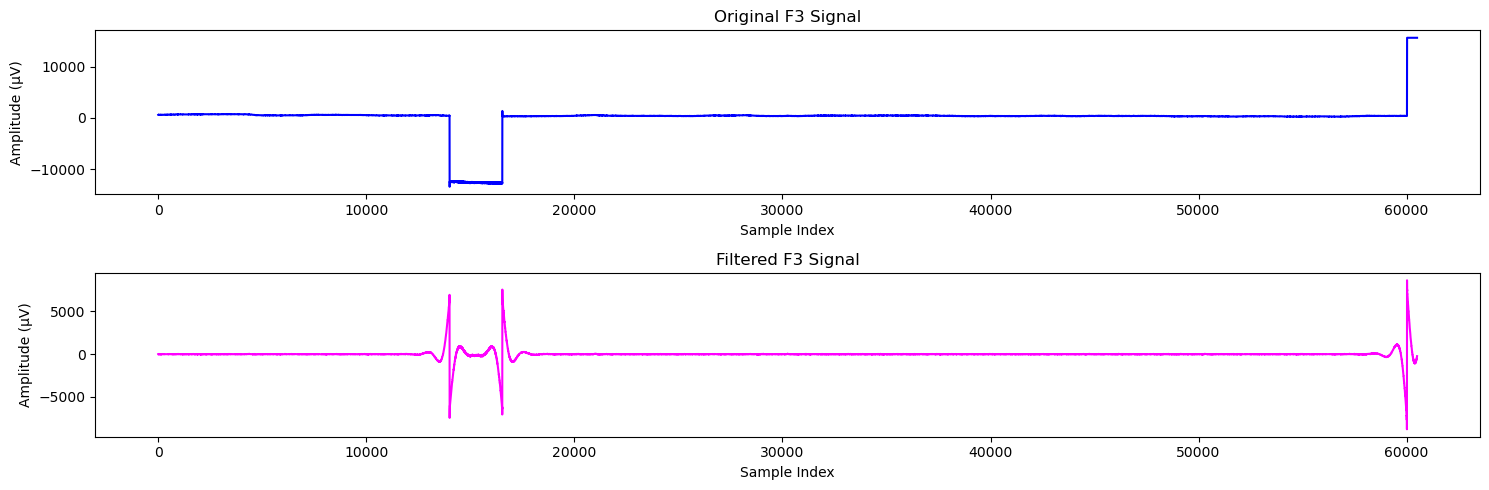

In [9]:
#Visual confirmation of the filtering effect on a sample EEG channel
channel_name = 'F3'  # Choose a channel to visualize
#Extract the original and filtered data for this channel
original_data_F3 = original_data.get_data(picks=[channel_name])[0] * 1e6
filtered_data_F3 = raw_pilot_restEC.get_data(picks=[channel_name])[0] * 1e6
#Plot the original and filtered signals for comparison
plt.figure(figsize=(15, 5))
plt.subplot(2, 1, 1)
plt.plot(original_data_F3, color='blue', label='Original F3')
plt.title('Original F3 Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (µV)')
plt.subplot(2, 1, 2)
plt.plot(filtered_data_F3, color='magenta', label='Filtered F3')
plt.title('Filtered F3 Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (µV)')
plt.tight_layout()
plt.show()

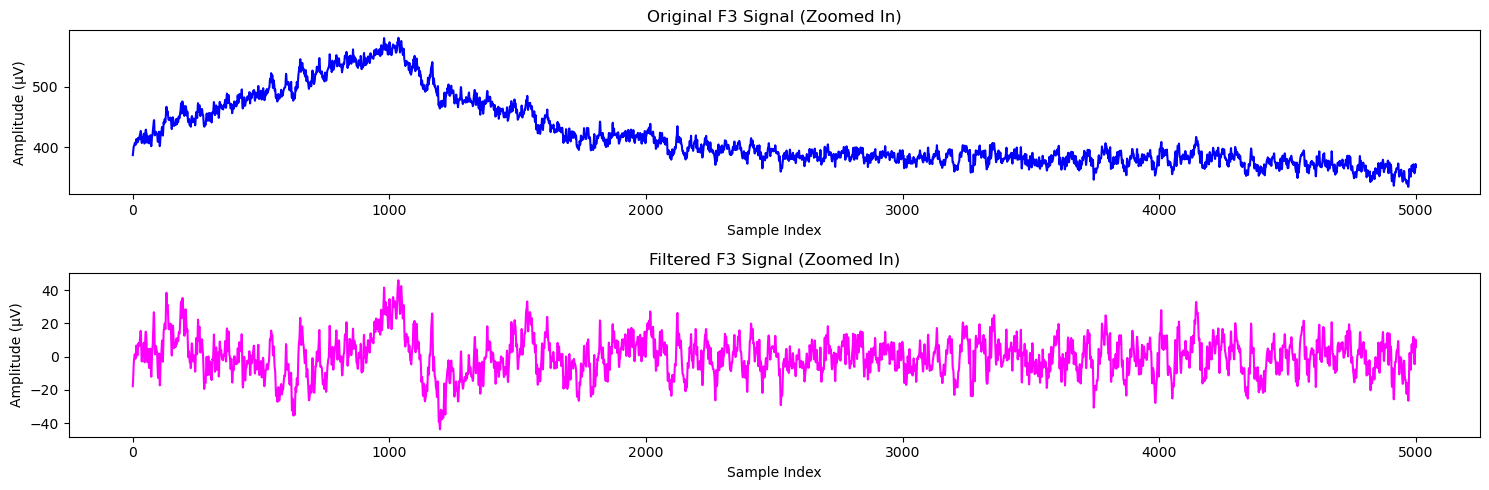

In [10]:
#zooming into a short, artefact-free stretch to visualize the filtering effect more clearly
start_sample = 20000
end_sample = 25000
plt.figure(figsize=(15, 5))
plt.subplot(2, 1, 1)
plt.plot(original_data_F3[start_sample:end_sample], color='blue', label='Original F3')
plt.title('Original F3 Signal (Zoomed In)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (µV)')
plt.subplot(2, 1, 2)
plt.plot(filtered_data_F3[start_sample:end_sample], color='magenta', label='Filtered F3')
plt.title('Filtered F3 Signal (Zoomed In)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (µV)')
plt.tight_layout()
plt.show()

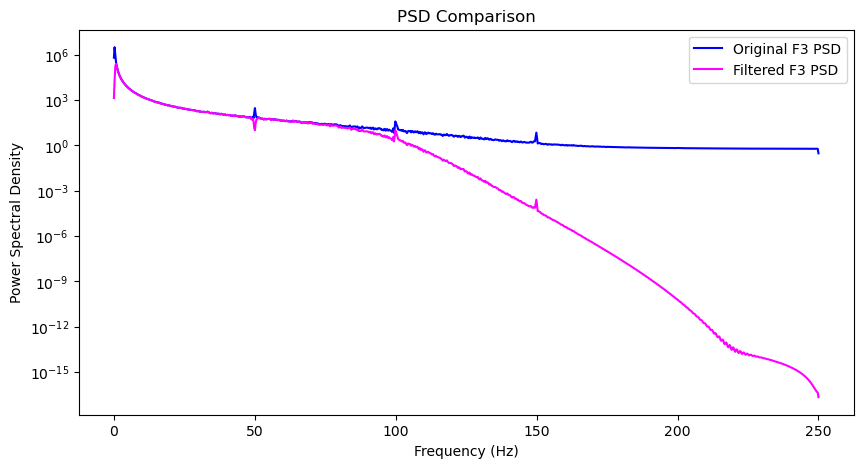

In [11]:
#validate the notch filter by checking the power spectral density (PSD) before and after filtering
#Compute the PSD of the original and filtered signals for the chosen channel
freqs_original, psd_original = scipy.signal.welch(original_data_F3, fs=raw_pilot_restEC.info['sfreq'], nperseg=2048)
freqs_filtered, psd_filtered = scipy.signal.welch(filtered_data_F3, fs=raw_pilot_restEC.info['sfreq'], nperseg=2048)

plt.figure(figsize=(10, 5))
plt.semilogy(freqs_original, psd_original, color='blue', label='Original F3 PSD')
plt.semilogy(freqs_filtered, psd_filtered, color='magenta', label='Filtered F3 PSD')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('PSD Comparison')
plt.legend()
plt.show()


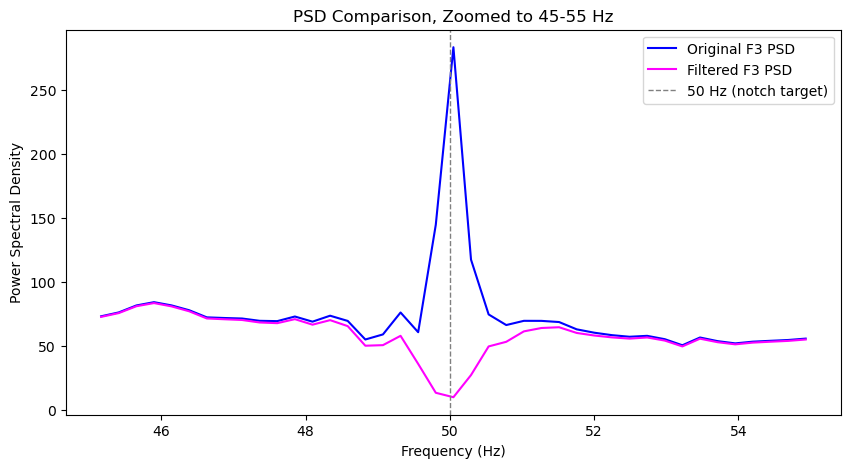

In [12]:
# Zoom into a narrow window around 50 Hz to check for the notch filter's effect directly.
# The notch filter (Q=100, notchfreq=50) has a bandwidth of ~50/100 = 0.5 Hz, so a broad
# 0-250 Hz view isn't fine-grained enough to see it clearly - this narrows the x-axis
# to 45-55 Hz specifically, where a working notch should show up as a sharp local dip.

freq_mask = (freqs_original >= 45) & (freqs_original <= 55)  # boolean mask for the frequency range of interest

plt.figure(figsize=(10, 5))
plt.plot(freqs_original[freq_mask], psd_original[freq_mask], color='blue', label='Original F3 PSD')
plt.plot(freqs_filtered[freq_mask], psd_filtered[freq_mask], color='magenta', label='Filtered F3 PSD')
# linear y-axis here, not semilogy - over this narrow a range, a linear scale makes
# a local dip easier to read than a log scale would
plt.axvline(50, color='gray', linestyle='--', linewidth=1, label='50 Hz (notch target)')  # reference line at the exact target frequency
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('PSD Comparison, Zoomed to 45-55 Hz')
plt.legend()
plt.show()

**`apply_filters` validation summary**

Time-domain check on channel F3 confirmed the highpass filter removed the large DC offset (~-15 to −28 mV raw) and slow drift, leaving oscillatory signal in a physiologically plausible +-20-40 µV range. PSD comparison confirmed the lowpass filter suppressed power above ~100 Hz relative to the unfiltered signal. A zoomed PSD (45-55 Hz) confirmed the notch filter specifically suppresses the 50 Hz mains peak (~280 -> ~5 PSD units), with the dip localized to roughly 49-51 Hz, consistent with the `Q=100` setting. The 100 Hz and 150 Hz mains harmonics remain largely unfiltered, as expected as the authors' notch filter only targets 50 Hz, not its harmonics.

**Open item for artefact detection**

Three step-like discontinuities were visually identified in channel F3's raw signal during filter validation (two around samples ~14,000–16,500, one near the recording's end, ~sample 60,000). These produced sharp transient spikes in the filtered signal (an expected highpass response to a step discontinuity, not a filtering bug). Plausibly the kind of artefact the authors' `detect_jumps` method is designed to catch - not addressed yet, flagged here so it isn't lost before artefact detection is implemented.

**status**

Goals 1-3 complete and validated on pilot subject `sub-87999321`:
1. Pilot subject confirmed (cohort member, both restEC/restEO available)
2. Channel inventory loaded and verified against `_channels.tsv`; types corrected
3. `bipolarEOG` and `apply_filters` implemented, matching the authors' published order and parameters; both validated (spot-check for bipolarEOG, time-domain + PSD checks for apply_filters)

In [13]:
## Correct EOG using athours method adapted from (Gratton et al. 1999)

#Artefact segment detection in VEOG
#Lowpass filter (15 Hz) 
VEOG_channel = raw_pilot_restEC.get_data(picks= 'VEOG')
Fs = raw_pilot_restEC.info['sfreq'] 
nyq = Fs*0.5
normal_cutoff = 15/nyq
b_l, a_l = scipy.signal.butter(4, normal_cutoff, btype='lowpass', analog=False)
VEOG_channel_filtered = scipy.signal.filtfilt(b_l, a_l, VEOG_channel) 
#Get the analytical signal using Hilbert transform
VEOG_1d = VEOG_channel_filtered[0]
n_samples = len(VEOG_1d)  # original length, before padding
N_pad = int(len(VEOG_1d) + len(VEOG_1d)*0.2)
VEOG_hil = scipy.signal.hilbert(VEOG_1d.copy(), N=N_pad, axis=-1)
VEOG_hilb = VEOG_hil[:n_samples]
amplenv = np.abs(VEOG_hilb)

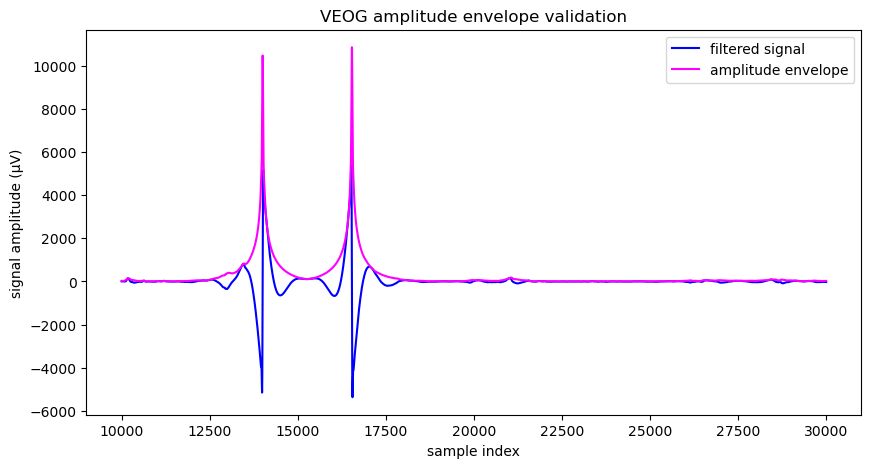

In [14]:
#Visual confirmation of VEOG amplitude envelope extraction
fig = plt.figure(figsize=(10,5))
start_sample = 10000
end_sample = 30000
sample_range = range(start_sample, end_sample)

plt.plot(sample_range, VEOG_1d[start_sample:end_sample] * 1e6, color='blue', label='filtered signal')
plt.plot(sample_range, amplenv[start_sample:end_sample] * 1e6, color='magenta', label='amplitude envelope')
plt.xlabel('sample index')
plt.ylabel('signal amplitude (µV)')
plt.title('VEOG amplitude envelope validation')
plt.legend()
plt.show()

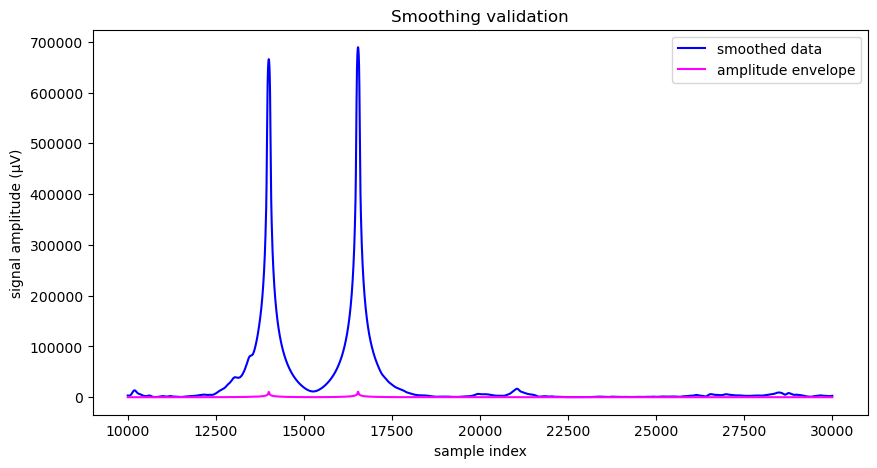

In [15]:
#Smoothing amplitude envelope with boxcar convolution
boxdata = scipy.signal.convolve(amplenv, scipy.signal.windows.boxcar(int(0.2*Fs)), mode ='same', method ='direct')
#visual confirmation of smoothed data 
fig = plt.figure(figsize=(10,5))
start_sample = 10000
end_sample = 30000
sample_range = range(start_sample, end_sample)

plt.plot(sample_range, boxdata[start_sample:end_sample] * 1e6, color='blue', label='smoothed data')
plt.plot(sample_range, amplenv[start_sample:end_sample] * 1e6, color='magenta', label='amplitude envelope')
plt.xlabel('sample index')
plt.ylabel('signal amplitude (µV)')
plt.title('Smoothing validation')
plt.legend()
plt.show()

## VEOG artefact-segment detection: signal preparation summary

Implemented the three-stage signal preparation used by the authors' `correct_EOG` method (Gratton et al., 1983/1999) as the input to threshold-based artefact detection, matching their published parameters:

1. **Lowpass filter (15 Hz)**: 4th-order Butterworth, applied via `scipy.signal.filtfilt` (zero-phase), isolating slow, blink-relevant frequency content from VEOG and excluding higher-frequency noise.
2. **Hilbert transform -> amplitude envelope**: computed the analytic signal via `scipy.signal.hilbert`, using 20% FFT padding to push edge-discontinuity artefacts (arising from the FFT's implicit periodicity assumption) out of the signal before truncating back to the original length. The envelope (`amplenv`) was obtained via `np.abs()` of the resulting complex-valued analytic signal.
3. **Boxcar smoothing**: convolved the envelope with an unnormalised 100-sample (200 ms) boxcar window (`scipy.signal.windows.boxcar`) to reduce sample-to-sample jitter, producing `boxdata`.

**Validation**: overlaid plots at each stage confirmed correct behaviour - the amplitude envelope traced the outer boundary of the filtered VEOG waveform without dipping below zero or crossing inside the waveform; the boxcar-smoothed version preserved the same peak locations and overall shape as the unsmoothed envelope, with visibly reduced jitter.

**Design note**: `boxdata` is on a substantially different amplitude scale to `amplenv` (~100x larger), since `scipy.signal.windows.boxcar` produces an unnormalised window (a moving sum, not a moving average) - this matches the authors' implementation exactly and does not affect the downstream z-score thresholding step, since z-scoring is invariant to positive linear scaling.

**Deviations from authors' code** (library version compatibility, no change in method):
- `np.int` -> `int()` (deprecated in current NumPy)
- `scipy.signal.boxcar` -> `scipy.signal.windows.boxcar` (relocated in current SciPy)

In [16]:
## Z-score thresholding to flag VEOG artefact samples

zdata = zscore(boxdata)
threshold = 0.2  # vthreshold, per authors' correct_EOG default

# One-sided threshold (deviation from authors' code) - see markdown below for rationale
Asamps = np.where(zdata > threshold)[0]

# Check the flagged fraction as a sanity check
flagged_fraction = len(Asamps) / len(boxdata)
print(f"Flagged samples: {len(Asamps)} / {len(boxdata)} ({flagged_fraction:.2%})")

Flagged samples: 5258 / 60500 (8.69%)


In [17]:
## Diagnostic: why the authors' two-sided condition was rejected

# Compare one-sided vs two-sided flagging to confirm the skew issue
flagged_high = np.where(zdata > threshold)[0]
flagged_low = np.where(zdata < -threshold)[0]
print(f"Positive-side flags: {len(flagged_high)}")
print(f"Negative-side flags: {len(flagged_low)}")
print(f"boxdata mean: {boxdata.mean():.4f}, std: {boxdata.std():.4f}")

Positive-side flags: 5258
Negative-side flags: 40581
boxdata mean: 0.0143, std: 0.0576


## VEOG z-score thresholding: deviation from authors' two-sided condition

The authors' `_detect_artifact` uses a two-sided z-score condition (`|zdata| > threshold`) to flag artefact samples. Applying this directly to `boxdata` at the authors' default `vthreshold = 0.2` flagged 75.8% of the recording as artefact, implausible given only two visually-confirmed blink events in this pilot subject's 2-minute recording.

**Diagnosis**: `boxdata` is non-negative by construction (derived from `np.abs()` of the Hilbert-transformed VEOG, then boxcar-convolved with a non-negative window). Its distribution is heavily right-skewed: mean (0.0143) < std (0.0576), driven by a small number of large blink-related peaks against a long, low-amplitude baseline. Z-scoring this skewed, always-positive signal pushes ordinary baseline samples to z = ~-0.25, which false-flags them under the negative-side condition (40,581 of the 46,000 flagged samples came from the negative side alone; only 5,258 came from genuine positive excursions).

**Resolution**: since `boxdata` cannot be meaningfully "artefactual" in the negative direction (a low envelope value simply means no eye movement, not a distinct artefact type), a one-sided threshold (`zdata > threshold`) was used instead. This is treated as a justified deviation from the authors' code rather than a silent fix, consistent with this project's approach of treating the authors' implementation as reference methodology rather than unquestioned ground truth (see also: the `.edf` docstring/code mismatch noted in `loaddata()`). With the one-sided condition, 8.69% of samples were flagged - consistent with the two blink events visible in exploratory plots.

In [18]:
#collapsing flagged samples (`Asamps`) into contiguous artefact segments (start/end sample pairs)
segments = []
begin = Asamps[0] #style simplification of the author's vstack-placeholder pattern

for e in range(len(Asamps)):
    if e >= len(Asamps)-1:
        end = Asamps[-1]
        segments.append([begin, end])
    elif Asamps[e+1] == Asamps[e]+1:
        continue
    else:
        end = Asamps[e]
        segments.append([begin, end])
        begin = Asamps[e+1]

Atrl = np.array(segments, dtype=int)
print(f'Number of segments: {Atrl.shape[0]}')
print(f'Segment boundaries:\n{Atrl}')

Number of segments: 3
Segment boundaries:
[[12851 14889]
 [15638 17480]
 [59117 60492]]


/var/folders/sj/n3g071kn3k5d875m963jywkr0000gn/T/ipykernel_65368/4289862780.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


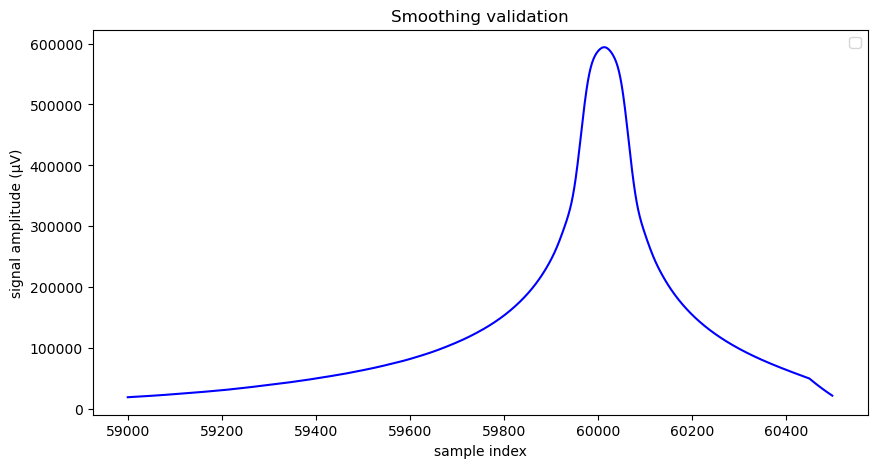

In [19]:
#visually inspect third segment 
#plot the boxdata in the window around sample 59000-60500 
#Smoothing amplitude envelope with boxcar convolution
boxdata = scipy.signal.convolve(amplenv, scipy.signal.windows.boxcar(int(0.2*Fs)), mode ='same', method ='direct')
#visual confirmation of smoothed data 
fig = plt.figure(figsize=(10,5))
start_sample = 59000
end_sample = 60500
sample_range = range(start_sample, end_sample)

plt.plot(sample_range, boxdata[start_sample:end_sample] * 1e6, color='blue')
plt.xlabel('sample index')
plt.ylabel('signal amplitude (µV)')
plt.title('Smoothing validation')
plt.legend()
plt.show()

### Open items (artefact detection, deferred)

- Three step-like discontinuities in F3 (identified during `apply_filters` validation): two near samples ~14,000-16,500, one near the recording's end (~sample 60,000).
- A third VEOG artefact segment (59117-60492, detected via z-score thresholding) has a peak location closely coinciding with the F3 discontinuity near sample 60,000, and sits at the very edge of the recording where filter/Hilbert-transform edge effects are more likely. Plausibly the same underlying event (non-ocular) rather than a genuine blink, or a filtering edge artefact - not yet distinguishable from the enveloped signal alone. To be resolved once jump/step-artefact detection (a separate, later goal) is implemented; until then this segment is retained in `Atrl` unmodified.

In [20]:
## Segment padding
## Extends each detected artefact segment proportionally to its own length,
## to capture the gradual rise/fall the threshold-crossing missed at the edges.

# Step 1: create a per-sample "artefact map" for the whole recording, all zeros to start.
artsamples = np.zeros(len(boxdata), dtype=int)

# Step 2: padding fraction - each segment gets extended by 30% of its own width,
# on both sides, per the authors' vpadding default.
padding = 0.3

# Step 3: only do this if segments were actually detected
if len(Atrl) > 0:
    # Step 4: loop over every detected segment (each row of Atrl is one [begin, end] pair)
    for i in range(Atrl.shape[0]):

        # Case A: this segment starts right at sample 0 (the very beginning of the recording)
        if Atrl[i, 0] == 0:
            pad_amount = int((Atrl[i, 1] - 0) * padding)
            artsamples[0 : Atrl[i, 1] + pad_amount] = 1

        # Case B: this segment ends at the very last sample of the recording
        elif Atrl[i, 1] == len(artsamples):
            pad_amount = int((Atrl[i, 1] - Atrl[i, 0]) * padding)
            artsamples[Atrl[i, 0] - pad_amount : len(artsamples)] = 1

        # Case C: general case - segment is somewhere in the middle, pad both sides
        else:
            pad_amount = int((Atrl[i, 1] - Atrl[i, 0]) * padding)
            artsamples[Atrl[i, 0] - pad_amount : Atrl[i, 1] + pad_amount] = 1

False
60904
Samples flagged before padding (from Atrl): 5255
Samples flagged after padding: 7587


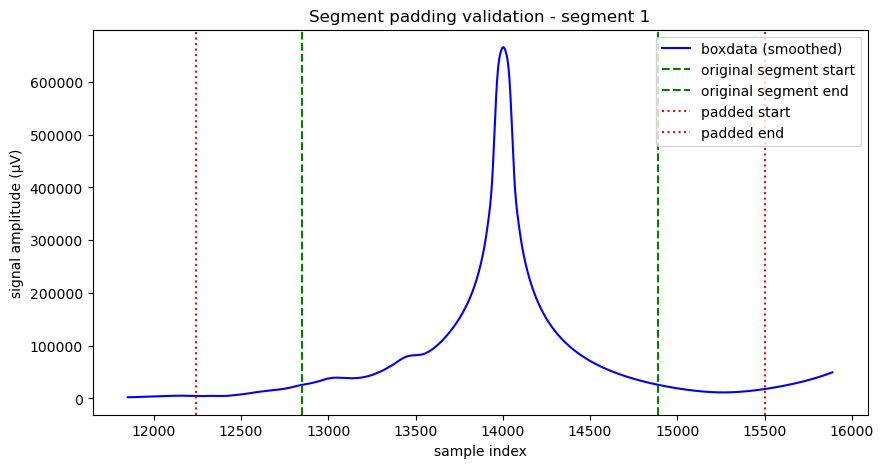

In [21]:
##Validation 
print(Atrl[2,1] == len(artsamples))  # confirm which case it took
print(Atrl[2,1] + int((Atrl[2,1]-Atrl[2,0])*0.3))  
print(f"Samples flagged before padding (from Atrl): {sum(end-begin for begin,end in Atrl)}")
print(f"Samples flagged after padding: {artsamples.sum()}")

## Visual check: segment 1, original vs padded boundaries

segment_1_start = Atrl[0,0]
segment_1_end = Atrl[0,1]

# padded boundaries, recomputed the same way as in the padding loop above
pad_amount_1 = int((segment_1_end - segment_1_start) * padding)
padded_start_1 = segment_1_start - pad_amount_1
padded_end_1 = segment_1_end + pad_amount_1

# add margin so the padded region is actually visible in the plot
margin = 1000
plot_start = segment_1_start - margin
plot_end = segment_1_end + margin
x = np.arange(plot_start, plot_end)

fig = plt.figure(figsize=(10,5))
plt.plot(x, boxdata[plot_start:plot_end] * 1e6, color='blue', label='boxdata (smoothed)')
plt.axvline(segment_1_start, color='green', linestyle='--', label='original segment start')
plt.axvline(segment_1_end, color='green', linestyle='--', label='original segment end')
plt.axvline(padded_start_1, color='red', linestyle=':', label='padded start')
plt.axvline(padded_end_1, color='red', linestyle=':', label='padded end')
plt.xlabel('sample index')
plt.ylabel('signal amplitude (µV)')
plt.title('Segment padding validation - segment 1')
plt.legend()
plt.show()


## Segment padding

Extended each detected VEOG artefact segment proportionally to its own width (30%, per authors' `vpadding` default), on both sides, to capture the gradual rise/fall of the envelope that simple threshold-crossing misses at the segment edges. Implemented as a per-sample binary map (`artsamples`), following the authors' three-case structure (segment touching the recording start, segment touching the recording end, general case).

**Validation**:
- Total flagged samples increased from 5,255 (pre-padding, from `Atrl`) to 7,587 (post-padding, `artsamples.sum()`) - consistent with proportional padding on three segments.
- Visual check on segment 1 (original boundaries 12851-14889) confirmed the padded boundaries extend sensibly into the envelope's low-amplitude shoulders on both sides, without overreaching into baseline or adjacent segments.

**Corrected bug (authors' code)**: the authors' first-branch (segment starting at sample 0) referenced `Atrl[0,1]` instead of `Atrl[i,1]` - a hardcoded reference to the first segment regardless of which segment `i` was actually being processed. Corrected to `Atrl[i,1]`.

**Noted fragility (authors' code, not corrected)**: the boundary check for "segment ends at the recording's final sample" uses exact equality (`Atrl[i,1] == len(artsamples)`). Segment 3 ends at sample 60492, 8 samples short of the recording's actual length (60500), so it narrowly missed this check and fell through to the general (both-sides-padding) case instead. The resulting padding request (up to sample 60904) exceeded the recording length; NumPy's slice-assignment silently clipped this to the array's actual end, producing the same correct result the boundary case would have given, but via an unintended path. Not corrected, since the practical output is unaffected here, but flagged as a brittleness in could behave differently under other data.

In [22]:
#re-deriving clean start/end segment pairs from the padded `artsamples` array 
# (needed before the regression step, since padded segments may now overlap).
starts = np.where(np.diff(artsamples) == 1)[0] + 1
ends = np.where(np.diff(artsamples) == -1)[0] + 1

# handle the edge case: recording ends while still inside an artefact
if artsamples[-1] == 1:
    ends = np.append(ends, len(artsamples))

# (for completeness, the mirror case - recording starts inside an artefact)
if artsamples[0] == 1:
    starts = np.insert(starts, 0, 0)
# stack them column-wise into a 2D array matching Atrl's [begin, end]
Atrl_padded = np.column_stack((starts, ends))
print(Atrl_padded.shape) #confirm 
#check if segment 1 and two got merged (2 artefacts and not 3):
print(Atrl_padded)


(2, 2)
[[12240 18032]
 [58705 60500]]


## Re-deriving contiguous segments from padded artefact map

Converted the per-sample `artsamples` binary map back into `[begin, end]` segment pairs using `np.diff` to detect 0->1 (start) and 1->0 (end) transitions, handling the edge case where the recording ends while still inside an artefact (segment 3's padding, clipped at the recording boundary - see prior note) by explicitly appending the final sample index.

**Result**: padding collapsed the original 3 segments into 2. Segments 1 and 2 (originally 12851-14889 and 15638-17480) had padded boundaries that overlapped (padded end of segment 1 = ~15495, padded start of segment 2 = ~15085), merging them into a single artefact window (12240-18032). Segment 3 remains separate (58705-60500, clipped at the recording's end).

This is the expected/intended behaviour of proportional padding on closely-spaced segments, and is why the per-sample `artsamples` representation was used rather than manually adjusting `[begin, end]` pairs - it handles overlap-driven merging automatically via the same contiguous-run-detection logic already validated in the earlier thresholding step, rather than requiring separate merge-handling code.

**Result**: `Atrl_padded` = `[[12240, 18032], [58705, 60500]]` - the final artefact segments to be used for the regression step.

## Single-channel, single-segment Gratton regression proof-of-concept (PoC)

**Objective**: validate the Gratton (1983) EOG-correction mechanism (regression coefficient 
estimation, tukey-tapered correction weight, subtraction) on one EEG channel and one artefact 
segment, before generalising to all 26 channels and both padded VEOG windows.

**Inputs**: `Fp1`, `VEOG` from `raw_pilot_restEC` (post `bipolarEOG`, `demean`, `apply_filters`); 
segment 1 from `Atrl_padded` (`[12240, 18032]`).

**Assumption going in (untested)**: segment 1 corresponds to a genuine blink event, per the 
Day 6 visual confirmation of its pre-padding components.

In [23]:
##Single-channel, single-segment Gratton regression proof-of-concept (PoC)

#Extract channel data
channel_name_Fp1 = 'Fp1'  # channel for PoC
channel_name_VEOG = 'VEOG'
filtereddata_Fp1 = raw_pilot_restEC.get_data(picks=[channel_name_Fp1])[0] * 1e6
filtereddata_VEOG = raw_pilot_restEC.get_data(picks=[channel_name_VEOG])[0] * 1e6
#Restrict to segment 1
Fp1_seg1 = filtereddata_Fp1[12240:18032]
VEOG_seg1 = filtereddata_VEOG[12240:18032]

##Estimate regression coefficient  
#reshape VEOG data to fit lstsq
a = VEOG_seg1.reshape(-1,1)
b = Fp1_seg1

x, residuals, rank, s = np.linalg.lstsq(a, b, rcond=None)
beta = x
print(f'The regression coeffecient beta for channel Fp1 in subject {pilot_subject_id} is: {beta}')

The regression coeffecient beta for channel Fp1 in subject sub-87999321 is: [-1.69181082]


β = -1.69 for Fp1. Before trusting this value, checking two things: (1) whether the sign is 
consistent with how Fp1 and VEOG actually co-vary in this segment, and (2) whether segment 1 
is physiologically plausible as a blink in the first place.

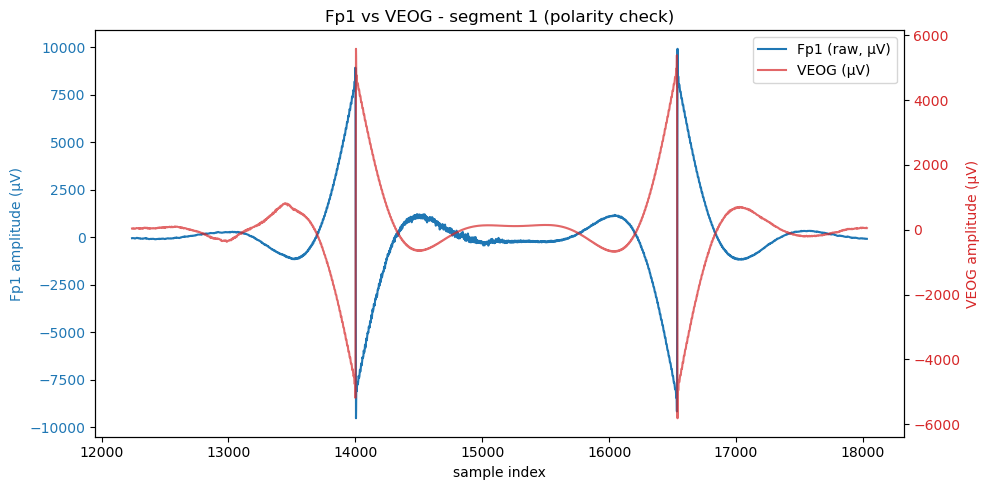

In [24]:
## Visual check: does Fp1 deflect same or opposite direction as VEOG during segment 1?

x_plot = np.arange(12240, 18032)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(x_plot, Fp1_seg1, color='tab:blue', label='Fp1 (raw, µV)')
ax1.set_xlabel('sample index')
ax1.set_ylabel('Fp1 amplitude (µV)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(x_plot, VEOG_seg1, color='tab:red', alpha=0.7, label='VEOG (µV)')
ax2.set_ylabel('VEOG amplitude (µV)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.title('Fp1 vs VEOG - segment 1 (polarity check)')
fig.tight_layout()
plt.show()

**Finding**: Fp1 and VEOG swing to ±9,000-10,000 µV - roughly 20-50x larger than a physiologically 
plausible blink (typically tens to a few hundred µV even at Fp1). The shape is also wrong for a 
blink: near-vertical onset/offset with a flat plateau in between, rather than a smooth rise-peak-fall. 
This looks like a step/pop artefact, not ocular activity. Checking the pre-`apply_filters` data next 
to rule out filtering (notch/highpass/lowpass) as the source of this shape.

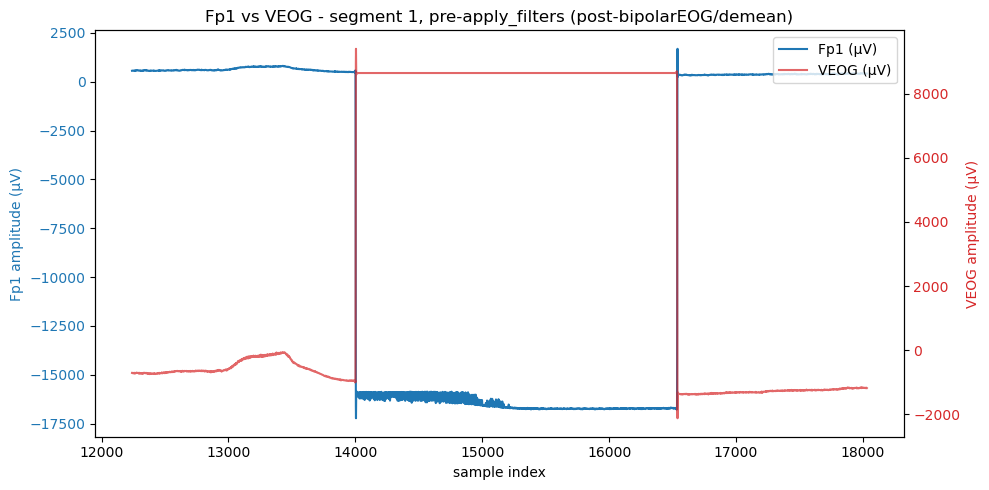

In [25]:
## Check whether the step shape pre-dates filtering (pre-apply_filters, post-bipolarEOG/demean)
channel_name_Fp1 = 'Fp1'
channel_name_VEOG = 'VEOG'
origdata_Fp1 = original_data.get_data(picks=[channel_name_Fp1])[0] * 1e6
origdata_VEOG = original_data.get_data(picks=[channel_name_VEOG])[0] * 1e6
# Restrict to segment 1
Fp1_seg1_orig = origdata_Fp1[12240:18032]
VEOG_seg1_orig = origdata_VEOG[12240:18032]
x_plot = np.arange(12240, 18032)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(x_plot, Fp1_seg1_orig, color='tab:blue', label='Fp1 (µV)')
ax1.set_xlabel('sample index')
ax1.set_ylabel('Fp1 amplitude (µV)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(x_plot, VEOG_seg1_orig, color='tab:red', alpha=0.7, label='VEOG (µV)')
ax2.set_ylabel('VEOG amplitude (µV)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.title('Fp1 vs VEOG - segment 1, pre-apply_filters (post-bipolarEOG/demean)')
fig.tight_layout()
plt.show()

## Segment 1: step-artefact finding - summary

The step shape (sharp onset ~14000, flat plateau, sharp offset ~16500) is present in the 
pre-`apply_filters` data too, ruling out filtering as the cause. Fp1 and VEOG, two physically 
distinct electrodes, step together at the same samples in the same rectangular shape, which 
is not consistent with a genuine, independent eye-movement event.

This location coincides with the two step-like F3 discontinuities flagged on Day 5 
(~14,000-16,500), and with the original pre-padding `Atrl` boundaries (`[12851,14889]`, 
`[15638,17480]`) - consistent with the z-score threshold catching the sharp on/off transitions 
of a single step, not two separate blinks.

**Conclusion**: segment 1 is very likely a non-ocular step/pop artefact, not a blink. It is not 
a valid case for the Gratton regression PoC as-is.

**Methodological note**: the authors' own pipeline (`autopreprocess_pipeline.py`) runs 
`correct_EOG` before `detect_jumps`, so this class of artefact would be regressed against as 
if it were ocular in the original method too - a limitation inherited from, not introduced by, 
this reimplementation.

**Decision**: rather than replicate this blind spot silently across all 163 subjects, add a 
lightweight amplitude-plausibility guard before fitting β on any segment (deviation, to be 
documented same as the one-sided z-score threshold change). Next: implement this guard, then 
re-select a genuinely clean segment/blink for the PoC.

In [26]:
## Amplitude-plausibility guard for candidate artefact segments

blink_amplitude_threshold_uv = 1000  # generous upper bound; genuine blinks typically <300-400 µV at Fp1/VEOG

valid_segments = []
excluded_segments = []

for seg_idx, (start, end) in enumerate(Atrl_padded):
    veog_segment = filtereddata_VEOG[start:end]
    peak_to_peak = veog_segment.max() - veog_segment.min()

    print(f"Segment {seg_idx} [{start}:{end}]: peak-to-peak VEOG = {peak_to_peak:.1f} µV", end=' ')

    if peak_to_peak > blink_amplitude_threshold_uv:
        print("-> EXCLUDED (implausible amplitude, likely non-ocular artefact)")
        excluded_segments.append((start, end))
    else:
        print("-> retained")
        valid_segments.append((start, end))

print(f"\n{len(valid_segments)} of {len(Atrl_padded)} segments retained for Gratton regression.")

Segment 0 [12240:18032]: peak-to-peak VEOG = 11404.8 µV -> EXCLUDED (implausible amplitude, likely non-ocular artefact)
Segment 1 [58705:60500]: peak-to-peak VEOG = 10234.7 µV -> EXCLUDED (implausible amplitude, likely non-ocular artefact)

0 of 2 segments retained for Gratton regression.


## Segment 1 & 2 both excluded - moving to restEO for the PoC

Both detected segments in this subject's restEC recording were excluded by the amplitude 
guard (11,404.8 µV and 10,234.7 µV peak-to-peak VEOG - both step artefacts, not blinks). 
Plausible explanation: restEC is eyes-closed, so blink frequency/amplitude is naturally lower 
than eyes-open, and none crossed the detection threshold as genuine ocular events.

**Decision**: switch to this subject's restEO (eyes-open) recording for the single-channel, 
single-segment PoC, since eyes-open resting state reliably contains frequent, clear blinks. 
The restEC finding is retained above as a documented result, not discarded - it's evidence 
that the amplitude guard is doing its job, and a concrete illustration of the authors' 
correct_EOG/detect_jumps ordering limitation.

In [27]:
## load restEO for the same pilot subject/session, fix channel types
# Replicating loading pattern exactly; only the condition string changes (restEC -> restEO)
pilot_restEO_file = pilot_subject_dir / f"{pilot_subject_id}_ses-1_task-restEO_eeg.bdf"
raw_pilot_restEO = mne.io.read_raw_bdf(pilot_restEO_file, preload=True)
raw_pilot_restEO.set_channel_types(new_types)  # reuse same type mapping as restEC

Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-87999321/ses-1/eeg/sub-87999321_ses-1_task-restEO_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 59999  =      0.000 ...   119.998 secs...


<RawBDF | sub-87999321_ses-1_task-restEO_eeg.bdf, 33 x 60000 (120.0 s), ~15.1 MiB, data loaded>

In [28]:
## bipolarEOG: derive VEOG/HEOG as electrode-pair differences, drop the four raw channels
eog_data_EO = raw_pilot_restEO.get_data(picks=['VPVA', 'VNVB', 'HPHL', 'HNHR'])
VEOG_EO = eog_data_EO[0, :] - eog_data_EO[1, :]  # vertical: above - below
HEOG_EO = eog_data_EO[2, :] - eog_data_EO[3, :]  # horizontal: left - right
bipolar_eog_data_EO = np.vstack((VEOG_EO, HEOG_EO))

info_EO = mne.create_info(ch_names=['VEOG', 'HEOG'], sfreq=raw_pilot_restEO.info['sfreq'], ch_types=['eog', 'eog'])
bipolar_eog_EO = mne.io.RawArray(bipolar_eog_data_EO, info_EO)
raw_pilot_restEO.add_channels([bipolar_eog_EO], force_update_info=True)
raw_pilot_restEO.drop_channels(['VPVA', 'VNVB', 'HPHL', 'HNHR'])  # replace, not retain - matches authors

Creating RawArray with float64 data, n_channels=2, n_times=60000
    Range : 0 ... 59999 =      0.000 ...   119.998 secs
Ready.


<RawBDF | sub-87999321_ses-1_task-restEO_eeg.bdf, 31 x 60000 (120.0 s), ~14.2 MiB, data loaded>

In [29]:
## Demean: subtract each channel's own time-average (type-based picks, not positional)
demean_picks_EO = mne.pick_types(raw_pilot_restEO.info, eeg=True, eog=True, ecg=True, emg=False, stim=False)
data_EO = raw_pilot_restEO.get_data(picks=demean_picks_EO)
channel_means_EO = data_EO.mean(axis=1, keepdims=True)
raw_pilot_restEO._data[demean_picks_EO, :] = data_EO - channel_means_EO  

In [30]:
## Apply_filters: notch (50Hz) -> highpass (0.5Hz) -> lowpass (100Hz), authors' order
# Keep a pre-filter copy for later comparison, same purpose as original_data for restEC
original_data_EO = raw_pilot_restEO.copy()

raw_pilot_restEO.apply_function(
    apply_filters,  # reuse function defined for restEC - no redefinition needed
    picks=mne.pick_types(raw_pilot_restEO.info, eeg=True, eog=True, ecg=True, emg=True, stim=False),
    channel_wise=True,
    Fs=raw_pilot_restEO.info['sfreq'], hpfreq=0.5, lpfreq=100, notchfreq=50, Q=100
)

<RawBDF | sub-87999321_ses-1_task-restEO_eeg.bdf, 31 x 60000 (120.0 s), ~14.2 MiB, data loaded>

In [31]:
## VEOG artefact-segment detection: lowpass -> Hilbert envelope -> boxcar smoothing -> z-score threshold
VEOG_channel_EO = raw_pilot_restEO.get_data(picks='VEOG')
Fs_EO = raw_pilot_restEO.info['sfreq']

# Step 1: isolate slow, blink-relevant frequency content (15 Hz lowpass)
b_l_EO, a_l_EO = scipy.signal.butter(4, 15 / (Fs_EO * 0.5), btype='lowpass', analog=False)
VEOG_filtered_EO = scipy.signal.filtfilt(b_l_EO, a_l_EO, VEOG_channel_EO)

# Step 2: Hilbert transform -> amplitude envelope (20% FFT padding avoids edge wraparound artefacts)
VEOG_1d_EO = VEOG_filtered_EO[0]
n_samples_EO = len(VEOG_1d_EO)
N_pad_EO = int(n_samples_EO * 1.2)
VEOG_hil_EO = scipy.signal.hilbert(VEOG_1d_EO.copy(), N=N_pad_EO, axis=-1)[:n_samples_EO]
amplenv_EO = np.abs(VEOG_hil_EO)

# Step 3: boxcar smoothing - merges sample-to-sample jitter into continuous elevated regions
boxdata_EO = scipy.signal.convolve(amplenv_EO, scipy.signal.windows.boxcar(int(0.2 * Fs_EO)), mode='same', method='direct')

# Step 4: one-sided z-score threshold (deviation from authors - see restEC markdown for rationale)
zdata_EO = zscore(boxdata_EO)
Asamps_EO = np.where(zdata_EO > threshold)[0]  # reuse threshold = 0.2 from restEC
print(f"Flagged: {len(Asamps_EO)} / {len(boxdata_EO)} ({len(Asamps_EO)/len(boxdata_EO):.2%})")

Flagged: 2358 / 60000 (3.93%)


In [32]:
## Collapse flagged samples into contiguous [begin, end] segments
segments_EO_raw = []
begin = Asamps_EO[0]
for e in range(len(Asamps_EO)):
    if e >= len(Asamps_EO) - 1:
        segments_EO_raw.append([begin, Asamps_EO[-1]])
    elif Asamps_EO[e+1] == Asamps_EO[e] + 1:
        continue
    else:
        segments_EO_raw.append([begin, Asamps_EO[e]])
        begin = Asamps_EO[e+1]
Atrl_EO = np.array(segments_EO_raw, dtype=int)
print(f"{len(Atrl_EO)} segments: {Atrl_EO.tolist()}")

8 segments: [[34, 114], [286, 403], [864, 991], [3543, 3554], [4602, 4691], [5599, 5638], [7045, 7131], [58198, 59999]]


In [33]:
## Segment padding: extend each segment by 30% of its own width (captures gradual rise/fall
## the threshold-crossing misses at the edges), then re-derive merged/clipped boundaries via per-sample map
artsamples_EO = np.zeros(len(boxdata_EO), dtype=int)

for i in range(Atrl_EO.shape[0]):
    if Atrl_EO[i, 0] == 0:  # segment starts at recording boundary
        pad = int((Atrl_EO[i, 1] - 0) * padding)
        artsamples_EO[0 : Atrl_EO[i, 1] + pad] = 1
    elif Atrl_EO[i, 1] == len(artsamples_EO):  # segment ends at recording boundary
        pad = int((Atrl_EO[i, 1] - Atrl_EO[i, 0]) * padding)
        artsamples_EO[Atrl_EO[i, 0] - pad : len(artsamples_EO)] = 1
    else:  # general case
        pad = int((Atrl_EO[i, 1] - Atrl_EO[i, 0]) * padding)
        artsamples_EO[Atrl_EO[i, 0] - pad : Atrl_EO[i, 1] + pad] = 1

# re-derive contiguous [start, end] pairs from the binary map via 0->1 / 1->0 transitions
starts_EO = np.where(np.diff(artsamples_EO) == 1)[0] + 1
ends_EO = np.where(np.diff(artsamples_EO) == -1)[0] + 1
if artsamples_EO[-1] == 1: ends_EO = np.append(ends_EO, len(artsamples_EO))  # recording ends inside a flagged region
if artsamples_EO[0] == 1: starts_EO = np.insert(starts_EO, 0, 0)             # recording starts inside a flagged region
Atrl_padded_EO = np.column_stack((starts_EO, ends_EO))
print(f"Atrl_padded_EO = {Atrl_padded_EO.tolist()}")

Atrl_padded_EO = [[10, 138], [251, 438], [826, 1029], [3540, 3557], [4576, 4717], [5588, 5649], [7020, 7156], [57658, 60000]]


In [34]:
## Amplitude-plausibility guard (deviation, see restEC markdown): exclude segments whose
## peak-to-peak VEOG amplitude is implausible for a genuine blink, before they reach the regression step
filtereddata_VEOG_EO = raw_pilot_restEO.get_data(picks=['VEOG'])[0] * 1e6

valid_segments_EO, excluded_segments_EO = [], []
for seg_idx, (start, end) in enumerate(Atrl_padded_EO):
    p2p = filtereddata_VEOG_EO[start:end].max() - filtereddata_VEOG_EO[start:end].min()
    print(f"Segment {seg_idx} [{start}:{end}]: peak-to-peak VEOG = {p2p:.1f} µV", end=' ')
    if p2p > blink_amplitude_threshold_uv:  # reuse threshold defined for restEC
        print("-> EXCLUDED"); excluded_segments_EO.append((start, end))
    else:
        print("-> retained"); valid_segments_EO.append((start, end))

print(f"\n{len(valid_segments_EO)} of {len(Atrl_padded_EO)} segments retained.")

Segment 0 [10:138]: peak-to-peak VEOG = 197.2 µV -> retained
Segment 1 [251:438]: peak-to-peak VEOG = 459.1 µV -> retained
Segment 2 [826:1029]: peak-to-peak VEOG = 576.6 µV -> retained
Segment 3 [3540:3557]: peak-to-peak VEOG = 67.9 µV -> retained
Segment 4 [4576:4717]: peak-to-peak VEOG = 411.4 µV -> retained
Segment 5 [5588:5649]: peak-to-peak VEOG = 303.6 µV -> retained
Segment 6 [7020:7156]: peak-to-peak VEOG = 418.7 µV -> retained
Segment 7 [57658:60000]: peak-to-peak VEOG = 18162.1 µV -> EXCLUDED

7 of 8 segments retained.


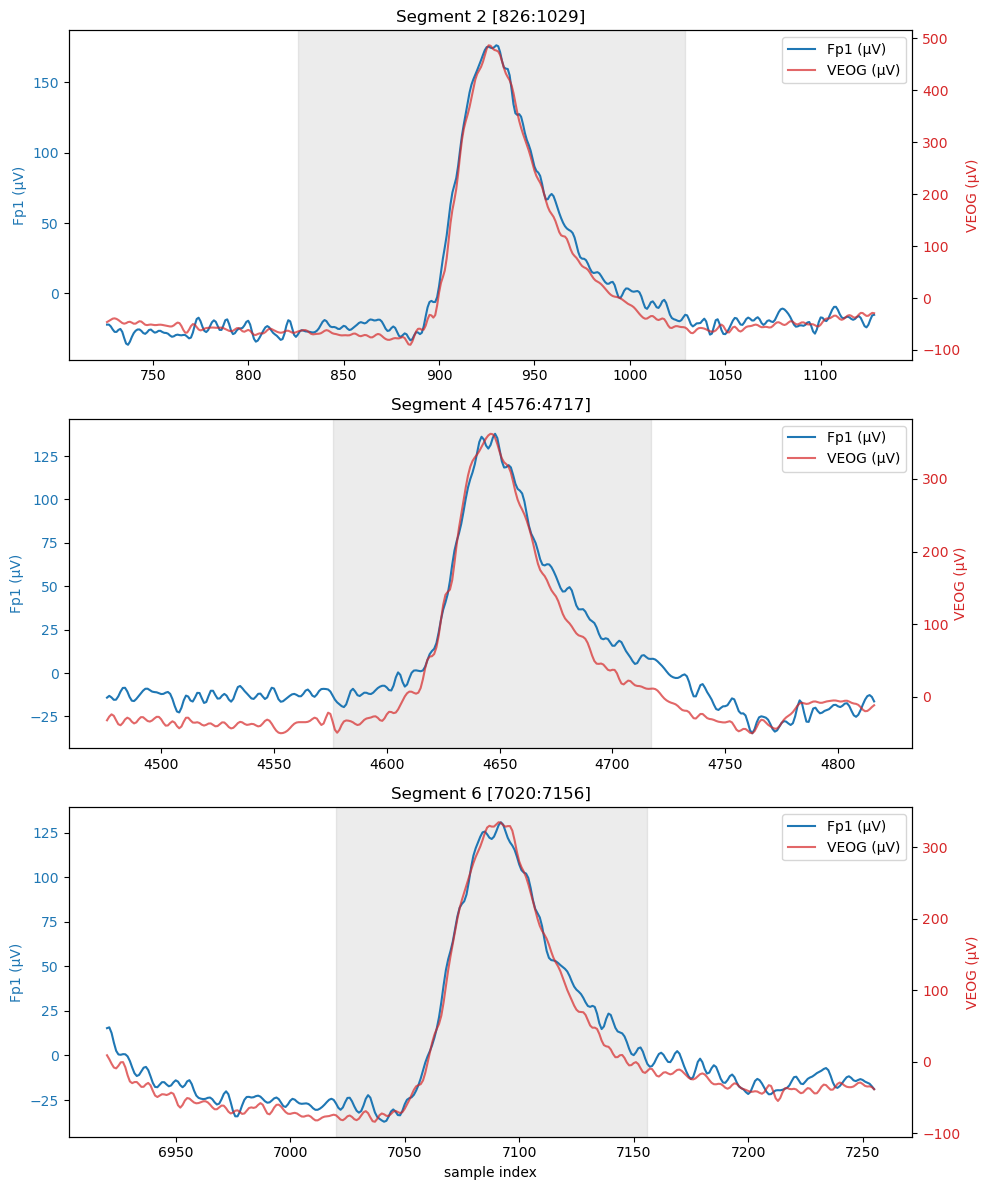

In [35]:
## Visual check: Fp1 vs VEOG shape for candidate PoC segments (2, 4, 6)
# Confirms these look like genuine blinks (smooth rise-peak-fall) rather than steps

filtereddata_Fp1_EO = raw_pilot_restEO.get_data(picks=['Fp1'])[0] * 1e6

candidate_segments = {2: (826, 1029), 4: (4576, 4717), 6: (7020, 7156)}
margin = 100  # extra samples either side, so the segment boundaries are visible in context

fig, axes = plt.subplots(len(candidate_segments), 1, figsize=(10, 4 * len(candidate_segments)))

for ax1, (seg_idx, (start, end)) in zip(axes, candidate_segments.items()):
    plot_start = max(0, start - margin)
    plot_end = end + margin
    x_plot = np.arange(plot_start, plot_end)

    ax1.plot(x_plot, filtereddata_Fp1_EO[plot_start:plot_end], color='tab:blue', label='Fp1 (µV)')
    ax1.axvspan(start, end, color='grey', alpha=0.15)  # shade the actual flagged segment
    ax1.set_ylabel('Fp1 (µV)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.plot(x_plot, filtereddata_VEOG_EO[plot_start:plot_end], color='tab:red', alpha=0.7, label='VEOG (µV)')
    ax2.set_ylabel('VEOG (µV)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    ax1.set_title(f'Segment {seg_idx} [{start}:{end}]')

axes[-1].set_xlabel('sample index')
fig.tight_layout()
plt.show()

Chose segment 2 for PoC as it is a single sharp symmetric peak, fully contained within the shaded padded region with baseline on both sides flat before and after.

In [36]:
##Single-channel, single-segment Gratton regression proof-of-concept (PoC)

#Extract channel data
channel_name_Fp1 = 'Fp1'  # channel for PoC
channel_name_VEOG = 'VEOG'
filtereddata_Fp1 = raw_pilot_restEO.get_data(picks=[channel_name_Fp1])[0] * 1e6
filtereddata_VEOG = raw_pilot_restEO.get_data(picks=[channel_name_VEOG])[0] * 1e6
#Restrict to segment 2
segment_2_start = 826
segment_2_end = 1029
Fp1_seg2 = filtereddata_Fp1[segment_2_start:segment_2_end]
VEOG_seg2 = filtereddata_VEOG[segment_2_start:segment_2_end]

##Estimate regression coefficient  
#reshape VEOG data to fit lstsq
a = VEOG_seg2.reshape(-1,1)
b = Fp1_seg2

x, residuals, rank, s = np.linalg.lstsq(a, b, rcond=None)
beta = x
print(f'The regression coeffecient beta for channel Fp1 in subject {pilot_subject_id} is: {beta}')

The regression coeffecient beta for channel Fp1 in subject sub-87999321 is: [0.3689841]


In [37]:
#Tukey taper
N = len(filtereddata_Fp1[826:1029])
Attaper = scipy.signal.windows.tukey(N, alpha=0.025)  # N = segment length
EOGweight = Attaper * beta  

#Constructing per sample correction
#create copy for correction
Fp1_corrected = filtereddata_Fp1.copy()

#Apply correction only within segment 2 - subtract the tapered, beta-scaled VEOG contribution
Fp1_corrected[segment_2_start:segment_2_end] -= EOGweight * filtereddata_VEOG[segment_2_start:segment_2_end]

#Validation: confirm nothing changed outside the segment
outside_before = np.concatenate([filtereddata_Fp1[:segment_2_start], filtereddata_Fp1[segment_2_end:]])
outside_after = np.concatenate([Fp1_corrected[:segment_2_start], Fp1_corrected[segment_2_end:]])

print(f"Unchanged outside segment: {np.array_equal(outside_before, outside_after)}")
print(f"Changed inside segment: {not np.array_equal(filtereddata_Fp1[segment_2_start:segment_2_end], Fp1_corrected[segment_2_start:segment_2_end])}")


Unchanged outside segment: True
Changed inside segment: True


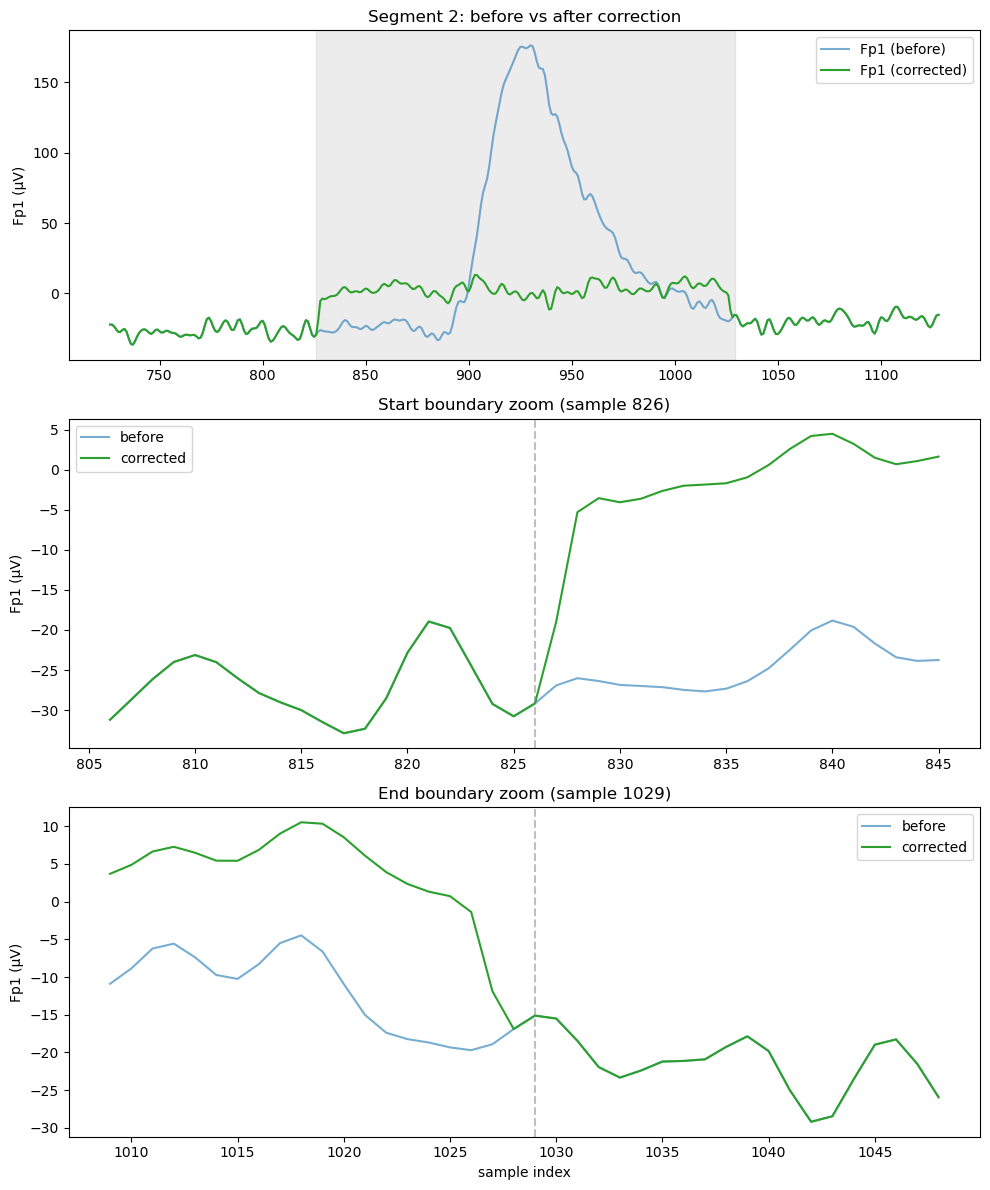

In [38]:
## Visual validation: before/after correction, segment + boundary zoom

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Full segment, with margin
margin = 100
plot_start, plot_end = segment_2_start - margin, segment_2_end + margin
x_plot = np.arange(plot_start, plot_end)
axes[0].plot(x_plot, filtereddata_Fp1[plot_start:plot_end], color='tab:blue', label='Fp1 (before)', alpha=0.6)
axes[0].plot(x_plot, Fp1_corrected[plot_start:plot_end], color='tab:green', label='Fp1 (corrected)')
axes[0].axvspan(segment_2_start, segment_2_end, color='grey', alpha=0.15)
axes[0].set_title('Segment 2: before vs after correction')
axes[0].set_ylabel('Fp1 (µV)')
axes[0].legend()

# Zoom on start boundary (826)
b_margin = 20
axes[1].plot(np.arange(segment_2_start - b_margin, segment_2_start + b_margin),
             filtereddata_Fp1[segment_2_start - b_margin:segment_2_start + b_margin], color='tab:blue', alpha=0.6, label='before')
axes[1].plot(np.arange(segment_2_start - b_margin, segment_2_start + b_margin),
             Fp1_corrected[segment_2_start - b_margin:segment_2_start + b_margin], color='tab:green', label='corrected')
axes[1].axvline(segment_2_start, color='grey', linestyle='--', alpha=0.5)
axes[1].set_title(f'Start boundary zoom (sample {segment_2_start})')
axes[1].set_ylabel('Fp1 (µV)')
axes[1].legend()

# Zoom on end boundary (1029)
axes[2].plot(np.arange(segment_2_end - b_margin, segment_2_end + b_margin),
             filtereddata_Fp1[segment_2_end - b_margin:segment_2_end + b_margin], color='tab:blue', alpha=0.6, label='before')
axes[2].plot(np.arange(segment_2_end - b_margin, segment_2_end + b_margin),
             Fp1_corrected[segment_2_end - b_margin:segment_2_end + b_margin], color='tab:green', label='corrected')
axes[2].axvline(segment_2_end, color='grey', linestyle='--', alpha=0.5)
axes[2].set_title(f'End boundary zoom (sample {segment_2_end})')
axes[2].set_xlabel('sample index')
axes[2].set_ylabel('Fp1 (µV)')
axes[2].legend()

fig.tight_layout()
plt.show()

## Summary: Gratton regression PoC validated

**Objective met**: single-channel (Fp1), single-segment Gratton EOG correction mechanism 
implemented and validated - β estimation (unweighted `lstsq`, matching authors), tukey-tapered 
per-sample correction weight (`alpha=0.025`), scoped subtraction (segment only, verified 
`np.array_equal` unchanged outside).

**Key finding, restEC**: both detected segments in this subject's restEC recording were step 
artefacts, not blinks (11,404.8 µV and 10,234.7 µV peak-to-peak VEOG - orders of magnitude 
above plausible blink amplitude). Confirmed pre-existing in pre-`apply_filters` data, ruling out 
filtering as the cause. Location coincides with Day 5's flagged F3 discontinuities. Both channels 
step synchronously, inconsistent with genuine independent ocular activity.

**Deviation added**: amplitude-plausibility guard (`blink_amplitude_threshold_uv = 1000`) 
excludes segments before they reach the regression, since the authors' pipeline runs 
`correct_EOG` before `detect_jumps` and would otherwise regress against artefacts like these 
as if they were ocular.

**Switched to restEO for the PoC**: eyes-open reliably contains genuine blinks. Full detection 
pipeline (`bipolarEOG -> demean -> apply_filters -> VEOG detection -> padding -> amplitude 
guard`) re-run on restEO: 8 candidate segments, 7 retained (67.9-576.6 µV), 1 excluded 
(18,162.1 µV, end-of-recording, same pattern as restEC's excluded segment). Segment 2 
(`826:1029`) selected: single clean symmetric peak, Fp1/VEOG co-varying (opposite of the 
step artefact's polarity), β = 0.369 (positive, as predicted from the polarity plot before running 
the regression).

**Validation**: peak amplitude reduced from ~180 µV to baseline noise level (~±10 µV) after 
correction. Confirmed `np.array_equal` match outside the segment, and a genuine change inside. 
Boundary zoom (samples 826, 1029) shows the taper does narrow the pre/post-correction 
discontinuity, but not to a fully gradual multi-sample ramp - `alpha=0.025` (the authors' default) 
tapers only ~2.5 samples on each side of a 203-sample segment, so the transition compresses 
to roughly 2-3 samples rather than eliminating the step outright. Consistent with the authors' 
specified parameters; noted here for precision rather than overstating "smooth."

In [39]:
##Duration guard 

#extract freequency 
fs = raw_pilot_restEO.info["sfreq"]
blink_duration_threshold = 100 #100 ms-> 0.100 * 500 = 50 samples
valid_segments_d_EO, excluded_segments_d_EO = [], []
for seg_idx, (start, end) in enumerate(valid_segments_EO):
    samp_dur = (end - start) / fs * 1000
    print(f"Segment {seg_idx} [{start}:{end}]: duration = {samp_dur:.1f} ms", end=' ')
    if samp_dur < blink_duration_threshold:
        print("-> EXCLUDED"); excluded_segments_d_EO.append((start, end))
    else:
        print("-> retained"); valid_segments_d_EO.append((start, end))

Segment 0 [10:138]: duration = 256.0 ms -> retained
Segment 1 [251:438]: duration = 374.0 ms -> retained
Segment 2 [826:1029]: duration = 406.0 ms -> retained
Segment 3 [3540:3557]: duration = 34.0 ms -> EXCLUDED
Segment 4 [4576:4717]: duration = 282.0 ms -> retained
Segment 5 [5588:5649]: duration = 122.0 ms -> retained
Segment 6 [7020:7156]: duration = 272.0 ms -> retained


**Duration guard applied to restEO segments**

Ran the duration guard on the amplitude guard's output (`valid_segments_EO`, 7 segments). 6 retained, 1 excluded:

- `[3540:3557]` excluded - 34.0 ms, well below the ~100 ms physiological lower bound for a genuine blink.
- All other segments retained, ranging 122.0-406.0 ms, consistent with plausible blink durations.

Final restEO segment list (`valid_segments_d_EO`), having passed both amplitude and duration guards:
`[10:138], [251:438], [826:1029], [4576:4717], [5588:5649], [7020:7156]`
This is the finalized segment list feeding into the generalized Gratton regression (all 26 channels).

In [40]:
## Build segment list with seg_id attached, for iteration
segments_EO = list(enumerate(valid_segments_d_EO))

# Confirm structure and count before using it in anything downstream
print(segments_EO)
print(f"\n{len(segments_EO)} segments ready for regression")

[(0, (np.int64(10), np.int64(138))), (1, (np.int64(251), np.int64(438))), (2, (np.int64(826), np.int64(1029))), (3, (np.int64(4576), np.int64(4717))), (4, (np.int64(5588), np.int64(5649))), (5, (np.int64(7020), np.int64(7156)))]

6 segments ready for regression


In [41]:
## Generalized Gratton regression: single channel (Fp1), all restEO segments

# Start from a fresh copy of the full-length filtered channel.
Fp1_corrected = filtereddata_Fp1.copy()
beta_rows = []

for seg_id, (start, end) in segments_EO:

    # slice this segment out of both channels
    Fp1_seg = filtereddata_Fp1[start:end]
    VEOG_seg = filtereddata_VEOG[start:end]

    # estimate beta for THIS segment only - not shared across segments
    a = VEOG_seg.reshape(-1, 1)
    b = Fp1_seg
    x, residuals, rank, s = np.linalg.lstsq(a, b, rcond=None)
    beta = x[0]  # x is a 1-element array; take the scalar

    # tukey taper, scaled by this segment's own beta
    # alpha=0.025 matches the authors' default, validated in the PoC
    N = end - start
    taper = scipy.signal.windows.tukey(N, alpha=0.025)
    eog_weight = taper * beta

    # scoped subtraction: only this segment's slice of the corrected array changes
    Fp1_corrected[start:end] -= eog_weight * VEOG_seg

    # record this (channel, segment) row for the beta DataFrame
    beta_rows.append({
        'channel': 'Fp1',
        'seg_id': seg_id,
        'seg_start': start,
        'seg_end': end,
        'n_samples': N,
        'beta': beta
    })

    print(f"Fp1, segment {seg_id} [{start}:{end}]: beta = {beta:.4f}")

Fp1, segment 0 [10:138]: beta = 0.3781
Fp1, segment 1 [251:438]: beta = 0.3877
Fp1, segment 2 [826:1029]: beta = 0.3690
Fp1, segment 3 [4576:4717]: beta = 0.3756
Fp1, segment 4 [5588:5649]: beta = 0.3745
Fp1, segment 5 [7020:7156]: beta = 0.3880


In [42]:
## Collect all segment betas into a single DataFrame for inspection

beta_df_Fp1 = pd.DataFrame(beta_rows)
beta_df_Fp1

,channel,seg_id,seg_start,seg_end,n_samples,beta
0,Fp1,0,10,138,128,0.378133
1,Fp1,1,251,438,187,0.387729
2,Fp1,2,826,1029,203,0.368984
3,Fp1,3,4576,4717,141,0.375580
4,Fp1,4,5588,5649,61,0.374480
5,Fp1,5,7020,7156,136,0.387966


In [43]:
## Validation: confirm correction is scoped correctly across all 6 segments

# Build a boolean mask marking every sample that falls OUTSIDE any segment.
mask = np.ones_like(filtereddata_Fp1, dtype=bool)
for _, (start, end) in segments_EO:
    mask[start:end] = False

outside_before = filtereddata_Fp1[mask]
outside_after = Fp1_corrected[mask]

print(f"Unchanged outside all segments: {np.array_equal(outside_before, outside_after)}")

Unchanged outside all segments: True


In [44]:
## Generalize to all 26 channels

# Filter channel_names down to only the 26 actual EEG channels (excludes VEOG/HEOG/ECG/EMG/Status)
eeg_channel_names = raw_pilot_restEO.copy().pick(picks='eeg').ch_names
# VEOG regressor - same for every channel, sliced fresh per segment inside the loop
filtereddata_VEOG = raw_pilot_restEO.get_data(picks=['VEOG'])[0] * 1e6

# Dict to hold each channel's own full-length corrected array, keyed by channel name
corrected_channels = {}

# Single list for all (channel, segment) beta rows across all 26 channels
beta_rows = []

for channel in eeg_channel_names:

    # this channel's own filtered data - the thing being corrected
    ch_data = raw_pilot_restEO.get_data(picks=[channel])[0] * 1e6

    # fresh corrected copy for this channel, started before its segment loop
    ch_corrected = ch_data.copy()

    for seg_id, (start, end) in segments_EO:

        # slice THIS channel (target) and VEOG (regressor) to the same segment
        ch_seg = ch_data[start:end]
        VEOG_seg = filtereddata_VEOG[start:end]

        # estimate beta for this (channel, segment) pair - not shared across segments
        a = VEOG_seg.reshape(-1, 1)
        b = ch_seg
        x, residuals, rank, s = np.linalg.lstsq(a, b, rcond=None)
        beta = x[0]

        # tukey taper, scaled by this segment's own beta
        N = end - start
        taper = scipy.signal.windows.tukey(N, alpha=0.025)
        eog_weight = taper * beta

        # scoped subtraction into this channel's corrected array
        ch_corrected[start:end] -= eog_weight * VEOG_seg

        beta_rows.append({
            'channel': channel,
            'seg_id': seg_id,
            'seg_start': start,
            'seg_end': end,
            'n_samples': N,
            'beta': beta
        })

        print(f"{channel}, segment {seg_id} [{start}:{end}]: beta = {beta:.4f}")

    # store this channel's finished corrected array before moving to the next channel
    corrected_channels[channel] = ch_corrected

# Build the DataFrame once, after all channels and segments are done
beta_df = pd.DataFrame(beta_rows)

Fp1, segment 0 [10:138]: beta = 0.3781
Fp1, segment 1 [251:438]: beta = 0.3877
Fp1, segment 2 [826:1029]: beta = 0.3690
Fp1, segment 3 [4576:4717]: beta = 0.3756
Fp1, segment 4 [5588:5649]: beta = 0.3745
Fp1, segment 5 [7020:7156]: beta = 0.3880
Fp2, segment 0 [10:138]: beta = 0.3359
Fp2, segment 1 [251:438]: beta = 0.3427
Fp2, segment 2 [826:1029]: beta = 0.3061
Fp2, segment 3 [4576:4717]: beta = 0.3232
Fp2, segment 4 [5588:5649]: beta = 0.3207
Fp2, segment 5 [7020:7156]: beta = 0.3430
F7, segment 0 [10:138]: beta = 0.2332
F7, segment 1 [251:438]: beta = 0.2193
F7, segment 2 [826:1029]: beta = 0.1948
F7, segment 3 [4576:4717]: beta = 0.2216
F7, segment 4 [5588:5649]: beta = 0.2179
F7, segment 5 [7020:7156]: beta = 0.2119
F3, segment 0 [10:138]: beta = 0.1823
F3, segment 1 [251:438]: beta = 0.1870
F3, segment 2 [826:1029]: beta = 0.1692
F3, segment 3 [4576:4717]: beta = 0.1671
F3, segment 4 [5588:5649]: beta = 0.1601
F3, segment 5 [7020:7156]: beta = 0.1858
Fz, segment 0 [10:138]: beta

In [45]:
#Frontal vs posterior validation
print(beta_df.groupby('channel')['beta'].mean().sort_values(ascending=False))

#confirm channel number
print(len(corrected_channels) == 26)

channel
Fp1    0.378812
Fp2    0.328610
F7     0.216460
F3     0.175270
Fz     0.154238
F4     0.139196
F8     0.110504
FC3    0.102251
FCz    0.093447
FC4    0.087954
C3     0.065946
Cz     0.060637
C4     0.057302
CP3    0.041410
CPz    0.040480
CP4    0.038709
T7     0.037410
T8     0.032654
Pz     0.024826
P3     0.024414
P4     0.022950
P7     0.014165
O1     0.004706
P8     0.004300
Oz    -0.000973
O2    -0.002110
Name: beta, dtype: float64
True


## Summary: Gratton regression generalised across all 26 EEG channels and 6 restEO segments

**Objective met**: Gratton (1983) EOG correction extended from the single-channel PoC to all 26
EEG channels x 6 validated restEO segments. Per-(channel, segment) beta, not shared across segments,
matching the authors' structure. Output: `corrected_channels` (dict, 26 keys) and `beta_df`
(156 rows).

**Validation**:
- Fp1's regenerated beta values exactly match the single-channel PoC (0.3781, 0.3877, 0.3690, 0.3756,
  0.3745, 0.3880) - confirms the loop is faithful to the validated mechanism.
- Unchanged-outside-segments check (mask, all 6 segments) confirmed `True`.
- Mean β by channel shows a clean, monotonic frontal-to-posterior gradient: Fp1 (0.379) and Fp2
  (0.329) highest, decreasing through frontal/central/parietal sites, bottoming out at Oz (-0.001)
  and O2 (-0.002) - small negative values consistent with fitting noise against noise where no
  genuine VEOG contamination exists, not a defect. Pattern fell out of 156 independently fitted
  regressions; consistent with expected spatial physiology of blink contamination.

In [46]:
## Correct EOG using authors' method adapted from Gratton et al. (1999)

# Artefact segment detection in HEOG
# Lowpass filter (15 Hz)
HEOG_channel = raw_pilot_restEO.get_data(picks='HEOG')
Fs_h = raw_pilot_restEO.info['sfreq']
nyq_h = Fs_h * 0.5
normal_cutoff_h = 15 / nyq_h
b_l_h, a_l_h = scipy.signal.butter(4, normal_cutoff_h, btype='lowpass', analog=False)
HEOG_channel_filtered = scipy.signal.filtfilt(b_l_h, a_l_h, HEOG_channel)
# Get the analytical signal using Hilbert transform
HEOG_1d = HEOG_channel_filtered[0]
n_samples_h = len(HEOG_1d)  # original length, before padding
N_pad_h = int(len(HEOG_1d) + len(HEOG_1d) * 0.2)
HEOG_hil = scipy.signal.hilbert(HEOG_1d.copy(), N=N_pad_h, axis=-1)
HEOG_hilb = HEOG_hil[:n_samples_h]
amplenv_h = np.abs(HEOG_hilb)
# Smoothing amplitude envelope with boxcar convolution
boxdata_h = scipy.signal.convolve(amplenv_h, scipy.signal.windows.boxcar(int(0.2 * Fs_h)), mode='same', method='direct')

## Trimmed z-scoring to flag HEOG artefact samples - top 2% of boxdata_h excluded
## from the reference mean/std so a single extreme artefact can't suppress
## detection elsewhere (see diagnostic cells below for why this was needed)
trim_pct = 2
cutoff_h = np.percentile(boxdata_h, 100 - trim_pct)
trim_mask_h = boxdata_h <= cutoff_h
trimmed_mean_h = boxdata_h[trim_mask_h].mean()
trimmed_std_h = boxdata_h[trim_mask_h].std()
zdata_h = (boxdata_h - trimmed_mean_h) / trimmed_std_h

threshold = 0.2  # hthreshold, per authors' correct_EOG default
Asamps_h = np.where(zdata_h > threshold)[0]

flagged_fraction = len(Asamps_h) / len(boxdata_h)
print(f"Trimmed mean = {trimmed_mean_h:.4f}, trimmed std = {trimmed_std_h:.4f}")
print(f"Flagged samples: {len(Asamps_h)} / {len(boxdata_h)} ({flagged_fraction:.2%})")

# Collapsing flagged samples (Asamps_h) into contiguous artefact segments (start/end sample pairs)
segments_h = []
begin_h = Asamps_h[0]

for e in range(len(Asamps_h)):
    if e >= len(Asamps_h) - 1:
        end_h = Asamps_h[-1]
        segments_h.append([begin_h, end_h])
    elif Asamps_h[e+1] == Asamps_h[e] + 1:
        continue
    else:
        end_h = Asamps_h[e]
        segments_h.append([begin_h, end_h])
        begin_h = Asamps_h[e+1]

Atrl_h = np.array(segments_h, dtype=int)
print(f'Number of segments: {Atrl_h.shape[0]}')
print(f'Segment boundaries:\n{Atrl_h}')

## Segment padding
## Extends each detected artefact segment proportionally to its own length,
## to capture the gradual rise/fall the threshold-crossing missed at the edges.

# per-sample artefact map for the whole recording, all zeros to start
artsamples_h = np.zeros(len(boxdata_h), dtype=int)

# padding fraction - each segment gets extended by 30% of its own width,
# on both sides, per the authors' hpadding default
padding = 0.3

if len(Atrl_h) > 0:
    for i in range(Atrl_h.shape[0]):

        # Case A: segment starts right at sample 0
        if Atrl_h[i, 0] == 0:
            pad_amount = int((Atrl_h[i, 1] - 0) * padding)
            artsamples_h[0 : Atrl_h[i, 1] + pad_amount] = 1

        # Case B: segment ends at the very last sample of the recording
        elif Atrl_h[i, 1] == len(artsamples_h):
            pad_amount = int((Atrl_h[i, 1] - Atrl_h[i, 0]) * padding)
            artsamples_h[Atrl_h[i, 0] - pad_amount : len(artsamples_h)] = 1

        # Case C: general case - segment is somewhere in the middle, pad both sides
        else:
            pad_amount = int((Atrl_h[i, 1] - Atrl_h[i, 0]) * padding)
            artsamples_h[Atrl_h[i, 0] - pad_amount : Atrl_h[i, 1] + pad_amount] = 1

## Re-derive contiguous [start, end] segment pairs from the padded artsamples_h map,
## via 0->1 / 1->0 transitions (same approach as cell 48 for VEOG)
starts_h = np.where(np.diff(artsamples_h) == 1)[0] + 1
ends_h = np.where(np.diff(artsamples_h) == -1)[0] + 1
if artsamples_h[-1] == 1: ends_h = np.append(ends_h, len(artsamples_h))  # recording ends inside a flagged region
if artsamples_h[0] == 1: starts_h = np.insert(starts_h, 0, 0)            # recording starts inside a flagged region
Atrl_padded_h = np.column_stack((starts_h, ends_h))
print(f"Atrl_padded_h = {Atrl_padded_h.tolist()}")

Trimmed mean = 0.0011, trimmed std = 0.0037
Flagged samples: 3432 / 60000 (5.72%)
Number of segments: 8
Segment boundaries:
[[  268   398]
 [  846   997]
 [ 4584  4691]
 [ 5563  5614]
 [ 6827  6910]
 [ 7041  7130]
 [44491 44554]
 [57249 59999]]
Atrl_padded_h = [[229, 437], [801, 1042], [4552, 4723], [5548, 5629], [6803, 6934], [7015, 7156], [44473, 44572], [56424, 60000]]


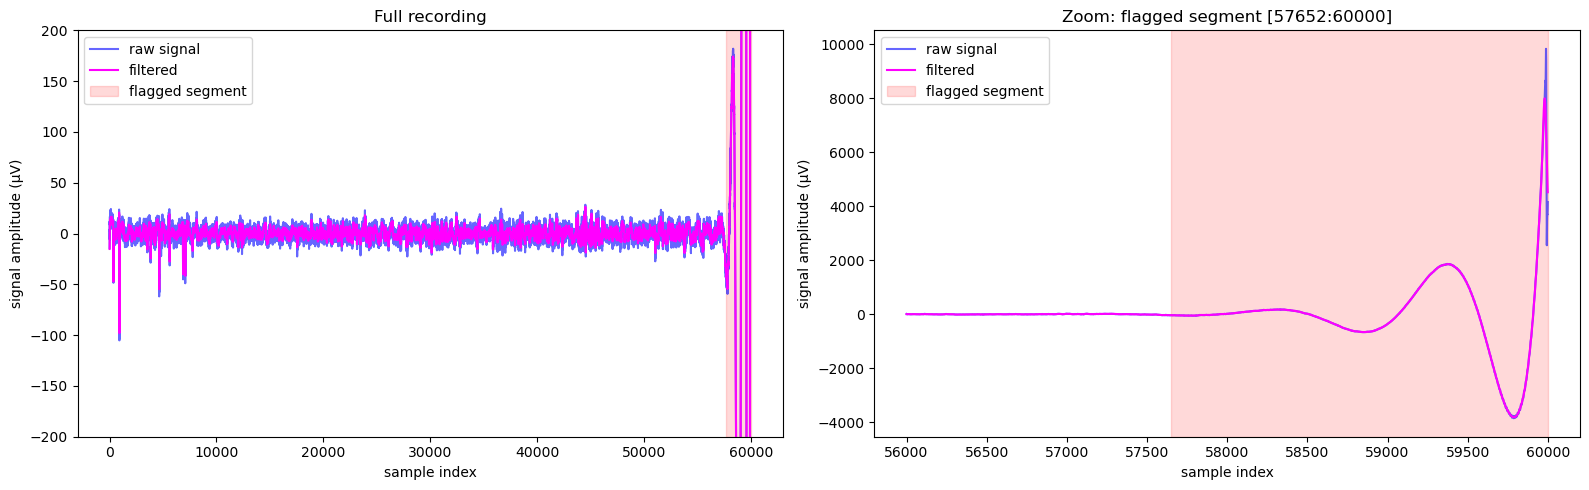

In [47]:
## Visual confirmation of HEOG filtering - full recording overview + zoom on flagged segment

HEOG_raw_1d = HEOG_channel[0]  # flatten (1, n_samples) -> (n_samples,)

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

#Left: full recording, to check for real saccadic structure elsewhere
full_range = range(0, len(HEOG_raw_1d))
axs[0].plot(full_range, HEOG_raw_1d * 1e6, color='blue', alpha=0.6, label='raw signal')
axs[0].plot(full_range, HEOG_1d * 1e6, color='magenta', label='filtered')
axs[0].axvspan(57652, 60000, color='red', alpha=0.15, label='flagged segment')
axs[0].set_ylim(-200, 200)
axs[0].set_xlabel('sample index')
axs[0].set_ylabel('signal amplitude (µV)')
axs[0].set_title('Full recording')
axs[0].legend()

#Right: zoom on the one flagged segment, to check if it looks genuine or artefactual 
zoom_start, zoom_end = 56000, 60000  # some padding either side of [57652:60000] for context
zoom_range = range(zoom_start, zoom_end)
axs[1].plot(zoom_range, HEOG_raw_1d[zoom_start:zoom_end] * 1e6, color='blue', alpha=0.6, label='raw signal')
axs[1].plot(zoom_range, HEOG_1d[zoom_start:zoom_end] * 1e6, color='magenta', label='filtered')
axs[1].axvspan(57652, 60000, color='red', alpha=0.15, label='flagged segment')
axs[1].set_xlabel('sample index')
axs[1].set_ylabel('signal amplitude (µV)')
axs[1].set_title('Zoom: flagged segment [57652:60000]')
axs[1].legend()

plt.tight_layout()
plt.show()

Full recording:    mean = 0.01, std = 0.04
Excluding artefact: mean = 0.00, std = 0.00
Std ratio (full / clean): 100.25x


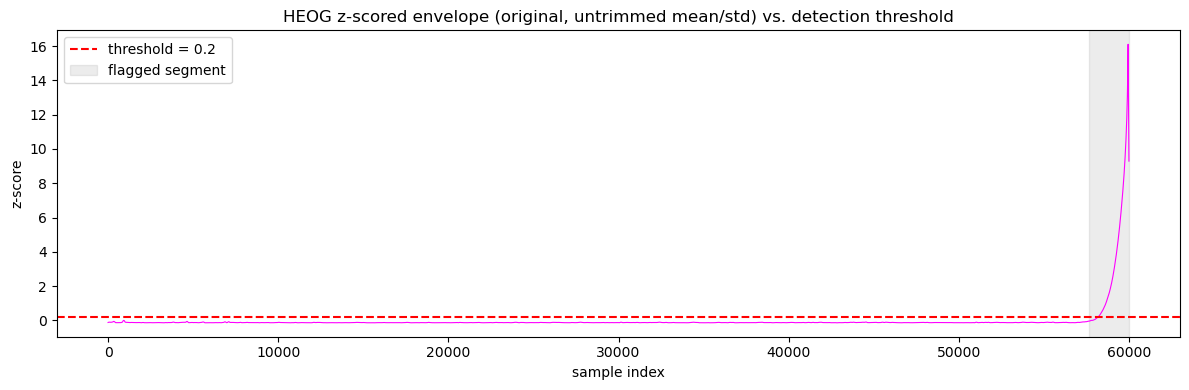

In [48]:
## Diagnostic: does the end-of-recording artefact distort the z-score statistics for the rest of the recording?
# Uses its own local z-scoring (zdata_h_original) rather than the ambient zdata_h, so this cell's output
# is correct regardless of what ran before it 

zdata_h_original = zscore(boxdata_h)  # standard mean/std, matching authors' original method

# Stats as currently computed - full recording, including the artefact
full_mean = boxdata_h.mean()
full_std = boxdata_h.std()

# Stats excluding the artefact region entirely (well before sample 57652)
clean_region = boxdata_h[:57000]
clean_mean = clean_region.mean()
clean_std = clean_region.std()

print(f"Full recording:    mean = {full_mean:.2f}, std = {full_std:.2f}")
print(f"Excluding artefact: mean = {clean_mean:.2f}, std = {clean_std:.2f}")
print(f"Std ratio (full / clean): {full_std / clean_std:.2f}x")

# Plot zdata_h_original with the detection threshold marked, to see directly
# whether genuine activity elsewhere ever approaches 0.2 under the original
# (untrimmed) z-scoring - this is what the fix below addresses
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(zdata_h_original, color='magenta', linewidth=0.8)
ax.axhline(threshold, color='red', linestyle='--', label=f'threshold = {threshold}')
ax.axvspan(57652, 60000, color='grey', alpha=0.15, label='flagged segment')
ax.set_xlabel('sample index')
ax.set_ylabel('z-score')
ax.set_title('HEOG z-scored envelope (original, untrimmed mean/std) vs. detection threshold')
ax.legend()
plt.tight_layout()
plt.show()

Full recording:    mean = 0.01, std = 0.05
Excluding artefact: mean = 0.00, std = 0.00
Std ratio (full / clean): 15.11x


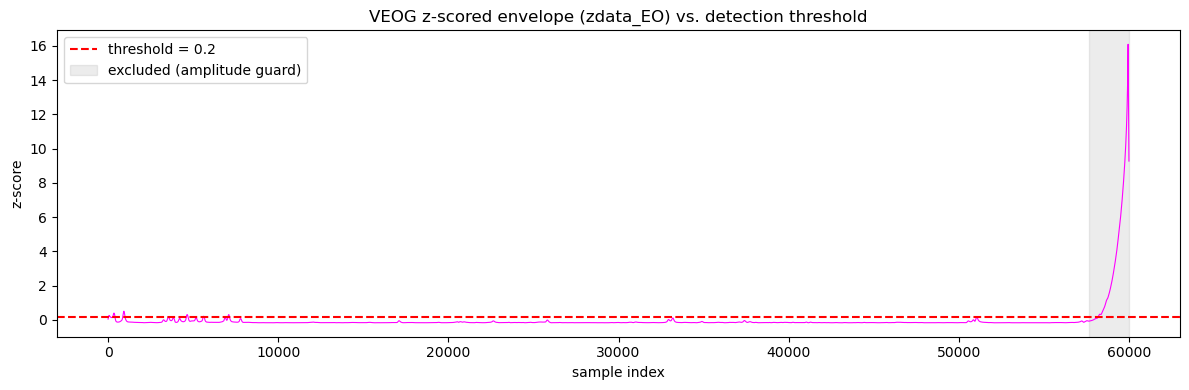

In [49]:
## Diagnostic: does VEOG have the same std-inflation problem as HEOG?

# Use a mask to exclude the actual known artefact region(s), rather than a hardcoded cutoff sample
mask_EO = np.ones(len(boxdata_EO), dtype=bool)
for start, end in excluded_segments_EO:
    mask_EO[start:end] = False

full_mean_EO = boxdata_EO.mean()
full_std_EO = boxdata_EO.std()

clean_mean_EO = boxdata_EO[mask_EO].mean()
clean_std_EO = boxdata_EO[mask_EO].std()

print(f"Full recording:    mean = {full_mean_EO:.2f}, std = {full_std_EO:.2f}")
print(f"Excluding artefact: mean = {clean_mean_EO:.2f}, std = {clean_std_EO:.2f}")
print(f"Std ratio (full / clean): {full_std_EO / clean_std_EO:.2f}x")

# Plot zdata_EO with the detection threshold, same as the HEOG diagnostic
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(zdata_EO, color='magenta', linewidth=0.8)
ax.axhline(threshold, color='red', linestyle='--', label=f'threshold = {threshold}')
for start, end in excluded_segments_EO:
    ax.axvspan(start, end, color='grey', alpha=0.15, label='excluded (amplitude guard)')
ax.set_xlabel('sample index')
ax.set_ylabel('z-score')
ax.set_title('VEOG z-scored envelope (zdata_EO) vs. detection threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [50]:
## Comparison check: does switching VEOG's z-scoring from mean/std to median/MAD
# change which samples get flagged (and therefore anything downstream)?

median_EO = np.median(boxdata_EO)
mad_EO = np.median(np.abs(boxdata_EO - median_EO))
zdata_EO_robust = 0.6745 * (boxdata_EO - median_EO) / mad_EO

Asamps_EO_robust = np.where(zdata_EO_robust > threshold)[0]

print(f"Current (mean/std):   {len(Asamps_EO)} samples flagged")
print(f"Robust (median/MAD):  {len(Asamps_EO_robust)} samples flagged")
print(f"Identical sample sets: {np.array_equal(Asamps_EO, Asamps_EO_robust)}")

# If not identical, show exactly how they differ
only_current = set(Asamps_EO) - set(Asamps_EO_robust)
only_robust = set(Asamps_EO_robust) - set(Asamps_EO)
print(f"Flagged only by current method: {len(only_current)} samples")
print(f"Flagged only by robust method:  {len(only_robust)} samples")

# Std ratio for reference 
print(f"\nmean/std:    mean={boxdata_EO.mean():.2f}, std={boxdata_EO.std():.2f}")
print(f"median/MAD:  median={median_EO:.2f}, MAD={mad_EO:.2f}")

Current (mean/std):   2358 samples flagged
Robust (median/MAD):  26166 samples flagged
Identical sample sets: False
Flagged only by current method: 0 samples
Flagged only by robust method:  23808 samples

mean/std:    mean=0.01, std=0.05
median/MAD:  median=0.00, MAD=0.00


## Summary: HEOG artefact detection - z-scoring fix

**Objective**: HEOG detection matching VEOG's pipeline (lowpass -> Hilbert -> boxcar -> z-threshold
-> collapse -> pad), per authors' identical VEOG/HEOG defaults (`threshold=0.2`, `padding=0.3`).

**Problem found**: standard mean/std z-scoring (authors' method, unmodified) detected only 1
segment for the whole recording - a non-ocular artefact at the very end (`[57652:60000]`) inflated
the recording-wide std by **100.25x**, suppressing detection of genuine saccadic activity visible
elsewhere in the raw signal. Same check run on VEOG found a smaller inflation (15.11x) that didn't
suppress detection, since VEOG's blinks were large enough to clear the threshold anyway - VEOG left
unchanged.

**Rejected fix**: median/MAD (robust z-scoring) flagged 43.6% of the recording - implausible.
`boxdata_h`'s right-skewed, mostly-baseline distribution collapses MAD near zero, making the
denominator hypersensitive instead of robust.

**Fix adopted**: trimmed mean/std - reference stats computed excluding the top 2% of `boxdata_h`;
full signal still z-scored against these. Smallest deviation from authors' method, percentile-based
so it generalises across subjects without a fixed µV cutoff.

**Result**: 8 candidate segments (5.72% flagged). 5 of 8 align closely in timing with already-
validated VEOG blink segments (e.g. `[268:398]` vs. VEOG's `[251:438]`) - independent evidence the
fix detects genuine signal. One segment has no VEOG counterpart (likely horizontal-only saccade).
End-of-recording artefact still correctly detected as a candidate (fix changed the reference stats,
not detection) - to be excluded via the amplitude guard, same treatment as restEC's step artefacts.

**Documented deviation**: HEOG z-scoring uses trimmed reference statistics (top 2% excluded) rather
than the full recording, to prevent one extreme artefact suppressing detection elsewhere. Threshold
(0.2) and one-sided comparison unchanged.

In [51]:
## Peak-to-peak HEOG amplitude for each candidate segment
# no threshold applied yet, looking at the actual values first to see if there's a natural separation
# between real saccades and the known artefact, same approach used to set VEOG's amplitude guard threshold.

for seg_idx, (start, end) in enumerate(Atrl_padded_h):
    p2p_h = HEOG_1d[start:end].max() - HEOG_1d[start:end].min()
    print(f"Segment {seg_idx} [{start}:{end}]: peak-to-peak HEOG = {p2p_h*1e6:.1f} µV")

Segment 0 [229:437]: peak-to-peak HEOG = 62.0 µV
Segment 1 [801:1042]: peak-to-peak HEOG = 118.7 µV
Segment 2 [4552:4723]: peak-to-peak HEOG = 64.1 µV
Segment 3 [5548:5629]: peak-to-peak HEOG = 46.7 µV
Segment 4 [6803:6934]: peak-to-peak HEOG = 51.5 µV
Segment 5 [7015:7156]: peak-to-peak HEOG = 49.6 µV
Segment 6 [44473:44572]: peak-to-peak HEOG = 45.0 µV
Segment 7 [56424:60000]: peak-to-peak HEOG = 11807.5 µV


In [52]:
## Amplitude-plausibility guard for HEOG candidate segments
# Reusing blink_amplitude_threshold_uv (1000 µV), same threshold as VEOG. Justified by the
# same clean-gap evidence: 7 segments cluster 45-119 µV, the artefact sits at 11,807.5 µV (~100x above), 
# so the threshold value doesn't need to be HEOG-specific - it's separating "plausible ocular contamination" 
# from "orders-of-magnitude artefact" in both channels, not fitting a saccade-specific amplitude range.

valid_segments_h, excluded_segments_h = [], []
for seg_idx, (start, end) in enumerate(Atrl_padded_h):
    p2p_h = HEOG_1d[start:end].max() - HEOG_1d[start:end].min()
    p2p_h_uv = p2p_h * 1e6
    print(f"Segment {seg_idx} [{start}:{end}]: peak-to-peak HEOG = {p2p_h_uv:.1f} µV", end=' ')
    if p2p_h_uv > blink_amplitude_threshold_uv:
        print("-> EXCLUDED"); excluded_segments_h.append((start, end))
    else:
        print("-> retained"); valid_segments_h.append((start, end))

print(f"\n{len(valid_segments_h)} of {len(Atrl_padded_h)} segments retained.")

Segment 0 [229:437]: peak-to-peak HEOG = 62.0 µV -> retained
Segment 1 [801:1042]: peak-to-peak HEOG = 118.7 µV -> retained
Segment 2 [4552:4723]: peak-to-peak HEOG = 64.1 µV -> retained
Segment 3 [5548:5629]: peak-to-peak HEOG = 46.7 µV -> retained
Segment 4 [6803:6934]: peak-to-peak HEOG = 51.5 µV -> retained
Segment 5 [7015:7156]: peak-to-peak HEOG = 49.6 µV -> retained
Segment 6 [44473:44572]: peak-to-peak HEOG = 45.0 µV -> retained
Segment 7 [56424:60000]: peak-to-peak HEOG = 11807.5 µV -> EXCLUDED

7 of 8 segments retained.


In [53]:
## Duration-plausibility guard for HEOG
# Same blink_duration_threshold (100 ms) and logic as VEOG's. 
# Applied sequentially to the amplitude guard's output.

fs_h = raw_pilot_restEO.info["sfreq"]
valid_segments_d_h, excluded_segments_d_h = [], []
for seg_idx, (start, end) in enumerate(valid_segments_h):
    samp_dur_h = (end - start) / fs_h * 1000
    print(f"Segment {seg_idx} [{start}:{end}]: duration = {samp_dur_h:.1f} ms", end=' ')
    if samp_dur_h < blink_duration_threshold:
        print("-> EXCLUDED"); excluded_segments_d_h.append((start, end))
    else:
        print("-> retained"); valid_segments_d_h.append((start, end))

print(f"\n{len(valid_segments_d_h)} of {len(valid_segments_h)} segments retained.")

Segment 0 [229:437]: duration = 416.0 ms -> retained
Segment 1 [801:1042]: duration = 482.0 ms -> retained
Segment 2 [4552:4723]: duration = 342.0 ms -> retained
Segment 3 [5548:5629]: duration = 162.0 ms -> retained
Segment 4 [6803:6934]: duration = 262.0 ms -> retained
Segment 5 [7015:7156]: duration = 282.0 ms -> retained
Segment 6 [44473:44572]: duration = 198.0 ms -> retained

7 of 7 segments retained.


In [54]:
## Gratton regression: HEOG, all 26 channels, all 7 valid segments.
# Regressed onto VEOG-corrected data, sequential per authors' order.
# Beta-plausibility guard: (channel, segment) pairs whose |beta| exceeds beta_plausibility_bound are left uncorrected
# for that slice, not silently applied - short-window regression on smooth signals can produce coincidentally 
# large fits (confirmed via diagnostic: segment 4's Fp1/HEOG traces were both clean, real signals, just similarly-shaped
# over that window - not an artefact, but not distinguishable from one via beta alone).

filtereddata_HEOG = HEOG_1d * 1e6
segments_h = list(enumerate(valid_segments_d_h))
beta_plausibility_bound = 1.0

corrected_channels_final = {}
beta_rows_h = []

for channel in eeg_channel_names:
    ch_data_veog_corrected = corrected_channels[channel]
    ch_corrected_final = ch_data_veog_corrected.copy()

    for seg_id, (start, end) in segments_h:
        ch_seg = ch_data_veog_corrected[start:end]
        HEOG_seg = filtereddata_HEOG[start:end]

        a = HEOG_seg.reshape(-1, 1)
        b = ch_seg
        x, residuals, rank, s = np.linalg.lstsq(a, b, rcond=None)
        beta_h = x[0]

        flagged = abs(beta_h) > beta_plausibility_bound

        if not flagged:
            N = end - start
            taper = scipy.signal.windows.tukey(N, alpha=0.025)
            eog_weight_h = taper * beta_h
            ch_corrected_final[start:end] -= eog_weight_h * HEOG_seg
        # if flagged: correction skipped, ch_corrected_final left as VEOG-corrected only for this slice

        beta_rows_h.append({
            'channel': channel, 'seg_id': seg_id, 'seg_start': start, 'seg_end': end,
            'n_samples': end - start, 'beta': beta_h, 'flagged': flagged
        })

    corrected_channels_final[channel] = ch_corrected_final

beta_df_h = pd.DataFrame(beta_rows_h)
print(f"{beta_df_h['flagged'].sum()} of {len(beta_df_h)} (channel, segment) betas flagged - correction skipped.")

4 of 182 (channel, segment) betas flagged - correction skipped.


In [55]:
## Log restEC's zero-valid-segment case explicitly, rather than leaving "no correction applied"
# implicit - matches the authors' own pattern of recording 0-artefact cases rather than silently passing through.

correction_log = {
    'restEC': {'VEOG': '0 valid segments (2 candidates, both excluded as non-ocular step artefacts)'},
}
print(correction_log)

{'restEC': {'VEOG': '0 valid segments (2 candidates, both excluded as non-ocular step artefacts)'}}


## Summary: HEOG Gratton regression - unit bug, leverage-point investigation, beta guard

**Objective met**: Gratton regression generalised across all 26 EEG channels x 7 validated HEOG
segments, regressed onto VEOG-corrected data (`corrected_channels`), matching the authors'
sequential VEOG-then-HEOG order (confirmed by tracing `correct_EOG`: `self.data` is updated in
place after VEOG correction, before HEOG regression runs against it).

**Bug found and fixed**: initial regression produced beta values in the tens of thousands to
millions - traced to a unit mismatch. The HEOG regressor (`HEOG_1d`) was still in volts (MNE's
`get_data()` default), while the regression target (`corrected_channels`, built with `* 1e6`) was
in µV. Fixed by scaling the regressor: `filtereddata_HEOG = HEOG_1d * 1e6`.

**Investigated, not a bug**: after the unit fix, segment 4 (`[6803:6934]`) still produced beta an
order of magnitude larger than the other 6 segments for several frontal channels (Fp1: -2.18 vs.
neighbours' 0.001-0.32). Diagnosed via two checks: (1) HEOG regressor variance in that window was
not unusually low relative to other segments (ruling out simple numerical instability), (2) direct
visual comparison of Fp1 (VEOG-corrected) and HEOG in that window showed two clean, genuine,
similarly-shaped deflections - not an artefact. Conclusion: short-window (131-sample) regression
on smooth, lowpass-filtered, autocorrelated signals can produce a coincidentally large but
mathematically valid fit when the two signals' shapes happen to align well over that specific
window - a known limitation of segment-scoped regression, not a data quality issue.

**Guard adopted**: a beta-plausibility bound (`beta_plausibility_bound = 1.0`, based on all other
values sitting under ~0.35) - `(channel, segment)` pairs exceeding it have correction skipped for
that slice (left as VEOG-corrected only), rather than applying an untrusted coefficient. Applied
automatically within the regression loop, generalising to any subject without requiring manual
per-subject visual inspection. 4 of 182 (channel, segment) pairs flagged and skipped (Fp1/Fp2/F7
segment 4; F7 segment 6).

**Documented deviations**:
- HEOG regressor requires explicit `* 1e6` conversion (volts -> µV) to match target channel units.
- Beta-plausibility guard (`beta_plausibility_bound = 1.0`) added, with no author precedent -
  addresses a limitation of segment-scoped least-squares regression on short windows, not
  addressed anywhere in the authors' original method.

**Output**: `corrected_channels_final` - VEOG + HEOG corrected data for all 26 channels, with
implausible fits safely excluded rather than silently applied.

**Also resolved**: restEC's zero-valid-segment case explicitly logged
(`correction_log`) rather than left implicit, matching the authors' own pattern of recording
0-artefact cases.

## Decision: artefact rejection strategy - Gratton vs. ICA reconsidered, autoreject vs. full author replication

Before continuing to artefact rejection, two methodological choices from the original plan were
revisited given new evidence, and both were reaffirmed rather than changed.

**Gratton (VEOG/HEOG correction) vs. ICA**: reconsidered given ICA's generally stronger blink-
removal performance and its ability to jointly address ocular and muscle artefacts. Reaffirmed
Gratton: the pipeline is already fully validated (26 channels x both eye channels, multiple
guards), and current literature does not show a decisive case for ICA over regression-based
correction for this kind of setup (dedicated EOG channels, moderate channel count) - it remains
a scenario-dependent trade-off, not a settled preference. Switching now would discard validated
work without a correspondingly clear benefit.

**autoreject vs. replicating the authors' 7 detect_ methods** (EMG, jumps, kurtosis, extreme
voltage swing, residual eyeblinks, electrode bridging, extreme correlations)**: the TDBRAIN
methods paper indicates these were adapted from the authors' own established clinical pipeline,
predating `autoreject`'s 2017 publication - i.e. a legacy-continuity choice for their 20-year
archive, not evidence against autoreject as a method. Full replication would require guard/
validation work at the same scale as this week's VEOG/HEOG work, seven times over - infeasible
given the project timeline. autoreject adopted as a well-validated, actively-maintained standard
tool (Option B).

**One documented gap in this choice**: autoreject operates on peak-to-peak amplitude only, not
frequency content. The authors' `detect_emg` specifically isolates the 75-95 Hz band, since
sustained muscle tension can elevate high-frequency content without necessarily producing a large
amplitude spike - meaning some EMG contamination could pass through autoreject undetected. Rather
than reimplementing `detect_emg` in full, a small, targeted bandpower-threshold supplement will be
added alongside autoreject to close this specific, evidenced gap - not a hedge against every
possible limitation, but a fix for the one concretely identified.

In [56]:
## HEOG artefact detection: restEC (never previously examined
# VEOG-restEC was checked and found clean, but HEOG-restEC has not yet been run).
# Adapted directly from the validated restEO HEOG cell, using the trimmed z-scoring fix from the start (not re-derived from scratch), 
# since restEC and restEO share the same end-of-recording artefact-prone pattern documented in the README -
# a whole-recording phenomenon (e.g. cap movement), not specific to one electrode pair. 
# A quick std-ratio check confirms whether the same problem is actually present here, rather than assuming it.
# All variables use an explicit _h_EC suffix to avoid overwriting the validated restEO HEOG variables (_h) still in memory.

# Lowpass filter (15 Hz)
HEOG_channel_EC = raw_pilot_restEC.get_data(picks='HEOG')
Fs_h_EC = raw_pilot_restEC.info['sfreq']
nyq_h_EC = Fs_h_EC * 0.5
normal_cutoff_h_EC = 15 / nyq_h_EC
b_l_h_EC, a_l_h_EC = scipy.signal.butter(4, normal_cutoff_h_EC, btype='lowpass', analog=False)
HEOG_channel_filtered_EC = scipy.signal.filtfilt(b_l_h_EC, a_l_h_EC, HEOG_channel_EC)

# Hilbert envelope
HEOG_1d_EC = HEOG_channel_filtered_EC[0]
n_samples_h_EC = len(HEOG_1d_EC)
N_pad_h_EC = int(len(HEOG_1d_EC) + len(HEOG_1d_EC) * 0.2)
HEOG_hil_EC = scipy.signal.hilbert(HEOG_1d_EC.copy(), N=N_pad_h_EC, axis=-1)
HEOG_hilb_EC = HEOG_hil_EC[:n_samples_h_EC]
amplenv_h_EC = np.abs(HEOG_hilb_EC)

# Boxcar smoothing
boxdata_h_EC = scipy.signal.convolve(amplenv_h_EC, scipy.signal.windows.boxcar(int(0.2 * Fs_h_EC)), mode='same', method='direct')

## Quick verification: does restEC's HEOG show the same untrimmed-std-inflation problem as restEO?
full_std_h_EC = boxdata_h_EC.std()
trim_pct = 2
cutoff_h_EC = np.percentile(boxdata_h_EC, 100 - trim_pct)
trim_mask_h_EC = boxdata_h_EC <= cutoff_h_EC
trimmed_mean_h_EC = boxdata_h_EC[trim_mask_h_EC].mean()
trimmed_std_h_EC = boxdata_h_EC[trim_mask_h_EC].std()
print(f"restEC HEOG std ratio (full / trimmed): {full_std_h_EC / trimmed_std_h_EC:.2f}x")

## Trimmed z-scoring (adopted directly, given restEO's precedent)
zdata_h_EC = (boxdata_h_EC - trimmed_mean_h_EC) / trimmed_std_h_EC

threshold = 0.2  # hthreshold, per authors' correct_EOG default - unchanged
Asamps_h_EC = np.where(zdata_h_EC > threshold)[0]

flagged_fraction_EC = len(Asamps_h_EC) / len(boxdata_h_EC)
print(f"Flagged samples: {len(Asamps_h_EC)} / {len(boxdata_h_EC)} ({flagged_fraction_EC:.2%})")

## Collapse flagged samples into contiguous segments
segments_h_EC = []
if len(Asamps_h_EC) > 0:
    begin_h_EC = Asamps_h_EC[0]
    for e in range(len(Asamps_h_EC)):
        if e >= len(Asamps_h_EC) - 1:
            segments_h_EC.append([begin_h_EC, Asamps_h_EC[-1]])
        elif Asamps_h_EC[e+1] == Asamps_h_EC[e] + 1:
            continue
        else:
            segments_h_EC.append([begin_h_EC, Asamps_h_EC[e]])
            begin_h_EC = Asamps_h_EC[e+1]

Atrl_h_EC = np.array(segments_h_EC, dtype=int)
print(f'Number of segments: {Atrl_h_EC.shape[0]}')
print(f'Segment boundaries:\n{Atrl_h_EC}')

## Segment padding (30%, per authors' hpadding default)
artsamples_h_EC = np.zeros(len(boxdata_h_EC), dtype=int)
padding = 0.3

if len(Atrl_h_EC) > 0:
    for i in range(Atrl_h_EC.shape[0]):
        if Atrl_h_EC[i, 0] == 0:
            pad_amount = int((Atrl_h_EC[i, 1] - 0) * padding)
            artsamples_h_EC[0 : Atrl_h_EC[i, 1] + pad_amount] = 1
        elif Atrl_h_EC[i, 1] == len(artsamples_h_EC):
            pad_amount = int((Atrl_h_EC[i, 1] - Atrl_h_EC[i, 0]) * padding)
            artsamples_h_EC[Atrl_h_EC[i, 0] - pad_amount : len(artsamples_h_EC)] = 1
        else:
            pad_amount = int((Atrl_h_EC[i, 1] - Atrl_h_EC[i, 0]) * padding)
            artsamples_h_EC[Atrl_h_EC[i, 0] - pad_amount : Atrl_h_EC[i, 1] + pad_amount] = 1

## Re-derive padded [start, end] segments
starts_h_EC = np.where(np.diff(artsamples_h_EC) == 1)[0] + 1
ends_h_EC = np.where(np.diff(artsamples_h_EC) == -1)[0] + 1
if len(artsamples_h_EC) > 0 and artsamples_h_EC[-1] == 1:
    ends_h_EC = np.append(ends_h_EC, len(artsamples_h_EC))
if len(artsamples_h_EC) > 0 and artsamples_h_EC[0] == 1:
    starts_h_EC = np.insert(starts_h_EC, 0, 0)
Atrl_padded_h_EC = np.column_stack((starts_h_EC, ends_h_EC)) if len(starts_h_EC) > 0 else np.empty((0, 2), dtype=int)
print(f"Atrl_padded_h_EC = {Atrl_padded_h_EC.tolist()}")

restEC HEOG std ratio (full / trimmed): 3.13x
Flagged samples: 6618 / 60500 (10.94%)
Number of segments: 2
Segment boundaries:
[[12827 17938]
 [58994 60499]]
Atrl_padded_h_EC = [[11294, 19471], [58543, 60500]]


In [57]:
## Amplitude-plausibility guard for HEOG-restEC candidates. 
# Prediction: both segments are the same non-ocular step artefacts already characterised for VEOG-restEC (thousands of uV,
# located at the same recording positions) - this guard tests that prediction rather than assuming it.

valid_segments_h_EC, excluded_segments_h_EC = [], []
for seg_idx, (start, end) in enumerate(Atrl_padded_h_EC):
    p2p_h_EC = HEOG_1d_EC[start:end].max() - HEOG_1d_EC[start:end].min()
    p2p_h_EC_uv = p2p_h_EC * 1e6
    print(f"Segment {seg_idx} [{start}:{end}]: peak-to-peak HEOG = {p2p_h_EC_uv:.1f} µV", end=' ')
    if p2p_h_EC_uv > blink_amplitude_threshold_uv:
        print("-> EXCLUDED"); excluded_segments_h_EC.append((start, end))
    else:
        print("-> retained"); valid_segments_h_EC.append((start, end))

print(f"\n{len(valid_segments_h_EC)} of {len(Atrl_padded_h_EC)} segments retained.")

Segment 0 [11294:19471]: peak-to-peak HEOG = 20045.2 µV -> EXCLUDED
Segment 1 [58543:60500]: peak-to-peak HEOG = 7470.2 µV -> EXCLUDED

0 of 2 segments retained.


In [58]:
## Update correction log: restEC HEOG also has 0 valid segments (both eye channels now
# confirmed clean/non-correctable for restEC - VEOG checked previously, HEOG checked here)

correction_log['restEC']['HEOG'] = ('0 valid segments (2 candidates, both excluded as non-ocular '
                                    'step artefacts - 20,045.2 µV and 7,470.2 µV, consistent in '
                                    'magnitude and location with the already-documented VEOG-restEC '
                                    'step artefacts)')
print(correction_log)

{'restEC': {'VEOG': '0 valid segments (2 candidates, both excluded as non-ocular step artefacts)', 'HEOG': '0 valid segments (2 candidates, both excluded as non-ocular step artefacts - 20,045.2 µV and 7,470.2 µV, consistent in magnitude and location with the already-documented VEOG-restEC step artefacts)'}}


In [59]:
## Duration guard for HEOG-restEC - runs on the amplitude guard's output. With 0 segments
# retained by the amplitude guard, this is a no-op for this subject, but kept as a standard
# pipeline step for consistency across subjects where it won't be trivial.

fs_h_EC = raw_pilot_restEC.info["sfreq"]
valid_segments_d_h_EC, excluded_segments_d_h_EC = [], []
for seg_idx, (start, end) in enumerate(valid_segments_h_EC):
    samp_dur_h_EC = (end - start) / fs_h_EC * 1000
    print(f"Segment {seg_idx} [{start}:{end}]: duration = {samp_dur_h_EC:.1f} ms", end=' ')
    if samp_dur_h_EC < blink_duration_threshold:
        print("-> EXCLUDED"); excluded_segments_d_h_EC.append((start, end))
    else:
        print("-> retained"); valid_segments_d_h_EC.append((start, end))

print(f"\n{len(valid_segments_d_h_EC)} of {len(valid_segments_h_EC)} segments retained.")


0 of 0 segments retained.


In [60]:
## Reconstruct a corrected MNE Raw object for restEO, since correction work so far has 
# produced plain numpy arrays (corrected_channels_final), not an MNE object - needed
# before epoching, since mne.make_fixed_length_epochs operates on Raw objects.
# Only the 26 EEG channels are replaced; VEOG/HEOG/ECG/EMG/Status stay as their filtered
# (uncorrected) values, since Gratton correction was only ever applied to EEG channels.
# restEC needs no equivalent step: 0 valid segments for both VEOG and HEOG means
# raw_pilot_restEC (already filtered) is the final corrected state.

raw_pilot_restEO_corrected = raw_pilot_restEO.copy()

for channel, corrected_uv in corrected_channels_final.items():
    ch_idx = raw_pilot_restEO_corrected.ch_names.index(channel)
    # corrected_channels_final is in µV (matching filtereddata_* convention);
    # MNE stores data in volts internally, so convert back before writing in.
    raw_pilot_restEO_corrected._data[ch_idx] = corrected_uv / 1e6

print("Corrected EEG channels written into raw_pilot_restEO_corrected:", 
      len(corrected_channels_final), "of", len(raw_pilot_restEO_corrected.ch_names), "total channels")

Corrected EEG channels written into raw_pilot_restEO_corrected: 26 of 31 total channels


In [61]:
## Epoch both conditions into 5-second, non-overlapping fixed-length windows.
# restEO uses the reconstructed corrected Raw object; restEC uses raw_pilot_restEC directly

epoch_duration = 5.0  # seconds

epochs_restEO = mne.make_fixed_length_epochs(raw_pilot_restEO_corrected, duration=epoch_duration, 
                                               overlap=0.0, preload=True)
epochs_restEC = mne.make_fixed_length_epochs(raw_pilot_restEC, duration=epoch_duration, 
                                               overlap=0.0, preload=True)

print(f"restEO: {len(epochs_restEO)} epochs of {epoch_duration}s")
print(f"restEC: {len(epochs_restEC)} epochs of {epoch_duration}s")

Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 24 events and 2500 original time points ...
0 bad epochs dropped
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 24 events and 2500 original time points ...
0 bad epochs dropped
restEO: 24 epochs of 5.0s
restEC: 24 epochs of 5.0s


## Decision: epoch length = 5 seconds, non-overlapping

Chosen as a compromise within the 4-8s range supported by the connectivity literature (epochs >4s give more accurate connectivity estimates, >6s are considered optimal), balanced against
epoch count: at 5s, ~24 epochs per condition per subject, more headroom before `autoreject`
dropout than the initially-considered 6s (~20 epochs), while remaining above the 4s floor rather
than settling at the minimum.

Deliberately not matching the authors' default (`trllength=2` in `segment()`): their default
is unjustified in the docstring and better suited to a general-purpose pipeline, not specifically
tuned for the phase/synchrony-based features (Kuramoto order parameter, metastability) this
project depends on, which need enough oscillation cycles per epoch for a stable phase estimate -
a 2s epoch cannot represent slower oscillations reliably. `autoreject`'s own documentation uses
3s epochs specifically for resting-state, frequency-sensitive analysis, reinforcing that longer
epochs are the norm for this kind of work, not the authors' shorter default.

Since this project classifies at the subject level (aggregating epoch-level features into one
vector per subject, not treating epochs as independent ML training samples), epoch count does
not affect classifier sample size - the choice was driven entirely by feature-estimate quality
and `autoreject` headroom, not by a need to maximise epochs for training data.

In [62]:
## autoreject needs electrode spatial positions (a "montage") to interpolate bad channels -
# not previously set anywhere in this pipeline, since correction/detection work only ever
# needed channel names and array indices, not physical positions. TDBRAIN uses standard
# 10-20/10-10 electrode naming, so MNE's built-in standard montage covers it directly.

standard_montage = mne.channels.make_standard_montage('standard_1020')
epochs_restEO.set_montage(standard_montage, on_missing='warn')
epochs_restEC.set_montage(standard_montage, on_missing='warn')

# Confirm all 26 EEG channels actually received a position 
n_positioned = sum(
    1 for name, ch in zip(epochs_restEO.info['ch_names'], epochs_restEO.info['chs'])
    if name in eeg_channel_names and not np.isnan(ch['loc'][:3]).all()
)
print(f"EEG channels with valid positions: {n_positioned} of {len(eeg_channel_names)}")

EEG channels with valid positions: 26 of 26


In [63]:
## Adopt autoreject (Jas, M., Engemann, D. A., Bekhti, Y., Raimondo, F., & Gramfort, A. (2017).
# Autoreject: Automated artifact rejection for MEG and EEG data. NeuroImage, 159, 417-429.
# https://doi.org/10.1016/j.neuroimage.2017.06.030): fit on restEO and restEC epochs separately, EEG channels only.

from autoreject import AutoReject

picks_eeg_EO = mne.pick_types(epochs_restEO.info, eeg=True)
picks_eeg_EC = mne.pick_types(epochs_restEC.info, eeg=True)

ar_EO = AutoReject(picks=picks_eeg_EO, random_state=42)
epochs_restEO_clean, reject_log_EO = ar_EO.fit_transform(epochs_restEO, return_log=True)

ar_EC = AutoReject(picks=picks_eeg_EC, random_state=42)
epochs_restEC_clean, reject_log_EC = ar_EC.fit_transform(epochs_restEC, return_log=True)

print(f"restEO: {len(epochs_restEO)} epochs -> {len(epochs_restEO_clean)} retained after autoreject")
print(f"restEC: {len(epochs_restEC)} epochs -> {len(epochs_restEC_clean)} retained after autoreject")

Running autoreject on ch_type=eeg


  0%|          | Creating augmented epochs : 0/26 [00:00<?,       ?it/s]

  0%|          | Computing thresholds ... : 0/26 [00:00<?,       ?it/s]

  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

  0%|          | n_interp : 0/3 [00:00<?,       ?it/s]

...

/opt/miniconda3/envs/eeg-rtms/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/eeg-rtms/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  0%|          | Fold : 0/10 [00:00<?,       ?it/s]





Estimated consensus=0.20 and n_interpolate=4


  0%|          | Repairing epochs : 0/24 [00:00<?,       ?it/s]

Dropped 1 epoch: 23
restEO: 24 epochs -> 23 retained after autoreject
restEC: 24 epochs -> 23 retained after autoreject


In [64]:
## Inspect reject_log to check specifically whether autoreject caught the F3 discontinuities
# (~samples 14,000-16,500, falling within epochs 5-6 at 5s/epoch) via interpolation 

f3_idx_EO = epochs_restEO.ch_names.index('F3')
f3_idx_EC = epochs_restEC.ch_names.index('F3')

# reject_log.labels: shape (n_epochs, n_channels). Per autoreject's convention:
# 0 = good, 1 = bad (not interpolated), 2 = interpolated
print("restEO F3 label per epoch:", reject_log_EO.labels[:, f3_idx_EO])
print("restEC F3 label per epoch:", reject_log_EC.labels[:, f3_idx_EC])

print("\nrestEO bad epochs (dropped):", np.where(reject_log_EO.bad_epochs)[0])
print("restEC bad epochs (dropped):", np.where(reject_log_EC.bad_epochs)[0])

restEO F3 label per epoch: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2.]
restEC F3 label per epoch: [0. 0. 0. 0. 2. 2. 2. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2.]

restEO bad epochs (dropped): [23]
restEC bad epochs (dropped): [23]


## Summary: autoreject adopted, benchmarked against known artefacts

**Objective**: adopt `autoreject` (Jas et al., 2017) for artefact rejection 

**Setup**: epoched VEOG+HEOG-corrected restEO and restEC data (5s, non-overlapping, 24 epochs
each). Required attaching a standard 10-20 montage (not previously needed anywhere in this
pipeline, since correction/detection work only used channel names/indices, not spatial
positions) - all 26/26 EEG channels matched successfully.

**Result**: both conditions dropped exactly 1 epoch (epoch 23, the final window) - the same
end-of-recording region already flagged as artefact-prone via VEOG and HEOG guards in both
conditions. `restEC`'s F3 channel was interpolated (not dropped) in epochs 4-7, directly
overlapping F3 discontinuities (~samples 14,000-16,500) - confirmed via
`reject_log.labels` rather than relying on the epoch-drop count alone, since a channel-specific
issue can be handled by interpolation within an otherwise-retained epoch. `restEO`'s F3 showed no
equivalent mid-recording flag, as expected (no reason for the same artefact to recur at the same
relative timestamp in an unrelated recording).

**Interpretation**: `autoreject` - using per-channel amplitude thresholds with no knowledge of the
z-score detection, guards, or visual inspection done- independently converged
on the same two artefact locations found by three separate prior methods. Strong convergent
validation for both the manual artefact-finding this week and this `autoreject` result.

**Caveat**: a `RuntimeWarning: Mean of empty slice` occurred during cross-validation, likely due to
the small epoch count (~24) relative to the 10-fold CV grid search. Not confirmed to have affected
the outcome, but the convergence with independently-known artefact locations is itself evidence
the result wasn't corrupted.

In [65]:
## EMG bandpower supplement: channel-within-epoch granularity, matching reject_log's shape,
# so the comparison against autoreject's existing flags is direct rather than approximate.
# Runs on the PRE-autoreject epochs (epochs_restEO/epochs_restEC, all 24 epochs, montage
# already attached) - not the _clean versions - since the point is to check what this
# catches that autoreject's own result did or didn't already cover.

emg_band = (75, 95)  # Hz, matching authors' detect_emg default
emg_threshold = 4    # SDs, matching authors' detect_emg default

def compute_emg_flags(epochs):
    # Bandpass to the EMG-relevant range - MNE's own filtering, not a hand-built Butterworth,
    # since this is explicitly a small supplement, not a detect_emg reimplementation.
    epochs_emg_band = epochs.copy().filter(l_freq=emg_band[0], h_freq=emg_band[1], 
                                             picks='eeg', verbose=False)
    data = epochs_emg_band.get_data(picks='eeg')  # shape: (n_epochs, n_channels, n_times)
    
    # Power per (epoch, channel): mean squared amplitude within each epoch's time window
    power = (data ** 2).mean(axis=2)  # shape: (n_epochs, n_channels)
    
    # Z-score per channel, across epochs - different channels have different baseline
    # power, so each channel's own epochs are the reference, not a single global scale.
    z_power = (power - power.mean(axis=0)) / power.std(axis=0)
    
    flagged = z_power > emg_threshold  # one-sided: only unusually high power is a concern
    return flagged, power

emg_flags_EO, emg_power_EO = compute_emg_flags(epochs_restEO)
emg_flags_EC, emg_power_EC = compute_emg_flags(epochs_restEC)

print(f"restEO: {emg_flags_EO.sum()} (epoch, channel) pairs flagged by EMG check")
print(f"restEC: {emg_flags_EC.sum()} (epoch, channel) pairs flagged by EMG check")

restEO: 26 (epoch, channel) pairs flagged by EMG check
restEC: 0 (epoch, channel) pairs flagged by EMG check


In [66]:
## Compare against autoreject's existing flags: does the EMG check catch anything
# autoreject's amplitude-based labels (0=good, 1=bad, 2=interpolated) missed entirely?

eeg_ch_names_EO = [epochs_restEO.ch_names[i] for i in mne.pick_types(epochs_restEO.info, eeg=True)]
eeg_ch_names_EC = [epochs_restEC.ch_names[i] for i in mne.pick_types(epochs_restEC.info, eeg=True)]

eeg_cols_EO = [reject_log_EO.ch_names.index(ch) for ch in eeg_ch_names_EO]
eeg_cols_EC = [reject_log_EC.ch_names.index(ch) for ch in eeg_ch_names_EC]

ar_flagged_EO = (reject_log_EO.labels != 0)[:, eeg_cols_EO]
ar_flagged_EC = (reject_log_EC.labels != 0)[:, eeg_cols_EC]

emg_only_EO = emg_flags_EO & ~ar_flagged_EO
emg_only_EC = emg_flags_EC & ~ar_flagged_EC

print(f"restEO: {emg_only_EO.sum()} (epoch, channel) pairs flagged by EMG check ONLY (missed by autoreject)")
print(f"restEC: {emg_only_EC.sum()} (epoch, channel) pairs flagged by EMG check ONLY (missed by autoreject)")

if emg_only_EO.sum() > 0:
    epoch_idx, ch_idx = np.where(emg_only_EO)
    for e, c in zip(epoch_idx, ch_idx):
        print(f"  restEO epoch {e}, channel {eeg_ch_names_EO[c]}")

if emg_only_EC.sum() > 0:
    epoch_idx, ch_idx = np.where(emg_only_EC)
    for e, c in zip(epoch_idx, ch_idx):
        print(f"  restEC epoch {e}, channel {eeg_ch_names_EC[c]}")

restEO: 0 (epoch, channel) pairs flagged by EMG check ONLY (missed by autoreject)
restEC: 0 (epoch, channel) pairs flagged by EMG check ONLY (missed by autoreject)


## Summary: EMG bandpower supplement - validated, retained as standing audit

**Objective**: address the one documented gap in adopting `autoreject` over the authors'
`detect_emg` - amplitude-only detection could in principle miss sustained muscle tension that
doesn't spike peak-to-peak amplitude, since EMG's frequency signature (75-95 Hz) isn't something
`autoreject` looks at directly.

**Method**: channel-within-epoch granularity, matching `reject_log`'s own shape for a direct
comparison. Bandpass filtered to 75-95 Hz (authors' `detect_emg` range) via MNE's built-in
filtering, power computed per (epoch, channel) as mean squared amplitude, z-scored per channel
across that channel's own epochs (not a single global threshold, since baseline power varies by
scalp location), threshold = 4 SD (authors' `detect_emg` default).

**Result**: 26 (epoch, channel) pairs flagged in restEO, 0 in restEC. Cross-checked against
`reject_log_EO`/`reject_log_EC` (subset to the 26 EEG-channel columns, matching order) - **0 of 26
flagged pairs were missed by `autoreject`**; every one was already marked bad or interpolated by
`autoreject`'s own amplitude-based thresholds.

**Interpretation**: for this subject, the theoretical gap did not materialise as an actual
detection failure - elevated 75-95 Hz power and elevated amplitude co-occurred closely enough
that `autoreject` already caught everything the frequency-specific check would have caught
separately. This is evidence for this one pilot subject, not a general finding - the correlation
between EMG frequency content and amplitude is not guaranteed to hold for every subject in the
163-subject cohort, so this result should not be read as "the gap is closed."

**Decision**: retain the EMG bandpower check as a standing audit alongside `autoreject` when
generalising to the full cohort, rather than treating it as validated-and-retired. Low marginal
cost per subject, and provides a documented per-subject check rather than an assumption carried
forward from n=1 that the amplitude/frequency correlation generalises.

In [67]:
## Save final preprocessed output (post-autoreject) to disk, MNE's native format.

output_dir = data_dir / "derivatives" / pilot_subject_id
output_dir.mkdir(parents=True, exist_ok=True)

epochs_restEO_clean.save(output_dir / f"{pilot_subject_id}_restEO-epo.fif", overwrite=True)
epochs_restEC_clean.save(output_dir / f"{pilot_subject_id}_restEC-epo.fif", overwrite=True)

print(f"Saved to {output_dir}")

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Saved to /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives/sub-87999321


In [68]:
## Save EMG audit results as a sparse per-subject record: 
# one row per flagged (epoch, channel) pair, not the full boolean matrix -
# most entries are False, so this is far more compact, and concatenates cleanly across subjects later into one cohort-wide audit table.

def emg_flags_to_rows(emg_flags, ar_flagged, ch_names, subject_id, condition):
    rows = []
    epoch_idx, ch_idx = np.where(emg_flags)
    for e, c in zip(epoch_idx, ch_idx):
        rows.append({
            'subject_id': subject_id,
            'condition': condition,
            'epoch': e,
            'channel': ch_names[c],
            'missed_by_autoreject': not ar_flagged[e, c]  # True = the gap actually mattered here
        })
    return rows

emg_audit_rows = (
    emg_flags_to_rows(emg_flags_EO, ar_flagged_EO, eeg_ch_names_EO, pilot_subject_id, 'restEO') +
    emg_flags_to_rows(emg_flags_EC, ar_flagged_EC, eeg_ch_names_EC, pilot_subject_id, 'restEC')
)

emg_audit_df = pd.DataFrame(emg_audit_rows, columns=['subject_id', 'condition', 'epoch', 'channel', 'missed_by_autoreject'])
emg_audit_df.to_csv(output_dir / f"{pilot_subject_id}_emg_audit.csv", index=False)

print(f"Saved {len(emg_audit_df)} flagged (epoch, channel) pairs to {output_dir}")
emg_audit_df

Saved 26 flagged (epoch, channel) pairs to /Users/romyweinstock/eeg-rtms-response-prediction/data/derivatives/sub-87999321


,subject_id,condition,epoch,channel,missed_by_autoreject
0,sub-87999321,restEO,23,Fp1,False
1,sub-87999321,restEO,23,Fp2,False
2,sub-87999321,restEO,23,F7,False
3,sub-87999321,restEO,23,F3,False
4,sub-87999321,restEO,23,Fz,False
5,sub-87999321,restEO,23,F4,False
6,sub-87999321,restEO,23,F8,False
7,sub-87999321,restEO,23,FC3,False
8,sub-87999321,restEO,23,FCz,False
9,sub-87999321,restEO,23,FC4,False
